# Charting Boulder: BVSD Enrollment
[Brian C. Keegan, Ph.D.](http://www.brianckeegan.com)  
September 2026

Released under a [MIT License](https://opensource.org/licenses/MIT).

The Boulder Valley School District's [Resilient Schools](https://www.bvsd.org/about/resilient-schools)
proposal recommends closing four elementary schools; the board votes September 22, 2026. Its
background slide lists five causes of enrollment decline as a flat list — declining births
(labeled national, state and local), an aging population, low housing inventory, "high cost of
living," and cheaper housing in surrounding districts.

This notebook is the analysis behind a column arguing two things. First, that the district's own
data support two divergent and credible demographic futures, and that it should say which one it
is planning for. Second, that two items on that list — falling births and housing cost — are not
one natural fact and one man-made one; they move together with the same fifty years of land-use
policy. Every claim here is descriptive and correlational. Nothing in this notebook identifies a
causal effect of zoning on births, prices, or enrollment.

### Environment

Every input is a tidy table under `data/processed/`, written by `bvsd-retrieval.ipynb`. This
notebook makes no network call, reads no API key and parses no source format. Rerun the retrieval
notebook to refresh the inputs; rerun this one to redo the argument. A standard Anaconda
distribution is enough.

In [1]:
import pandas as pd
import numpy as np

pd.options.display.max_columns = 100

%matplotlib inline
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

import warnings
from pathlib import Path

sb.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# Colour scheme, stated once. The portfolio default is city blue and county green; this piece
# departs from it because its subject is Boulder against a comparison, not the city against its
# county. Boulder, whether city or county, is red wherever it is the subject; the peer basket is
# blue; the nation, Colorado and the Front Range are green; the Boulder County ring towns are
# green in the permits figure; context is gray. The two forecast forks are blue (the state's
# view) and red (the cohort view computed here). Red and green sit close under deuteranopia, so
# every figure that draws both also names each series in text and prints its values; colour is
# never the only thing that separates them.
BOULDER_C, PEER_C, NATION_C, CONTEXT = 'tab:red', 'tab:blue', 'tab:green', 'tab:gray'
RING_C = 'tab:green'
SDO_COLOR, HP_COLOR = 'tab:blue', BOULDER_C
VOCAB_COLORS_D = {'Preservation': 'tab:green', 'Children & schools': 'tab:blue',
                  'Housing affordability': 'tab:orange'}

PROC = Path('data/processed')
OUT = Path('output')
OUT.mkdir(exist_ok=True)

# The board vote this column is pegged to. A date, not a computed value.
VOTE_DATE = 'September 22, 2026'
print('setup ok · vote date', VOTE_DATE)

setup ok · vote date September 22, 2026


## Load the place registry and the decennial age tables

The place registry names the 31 places this piece compares: the City of Boulder, the five other
Boulder County municipalities, and the 25-city peer basket carried over from the
[2025-06 population piece](https://github.com/brianckeegan/charting-boulder/tree/main/2025-06-population).
The age tables are built from [IPUMS NHGIS](https://www.nhgis.org/) decennial extracts by
`bvsd-retrieval.ipynb`. The 1990 and 2000 censuses publish single years of age only below 20, so
the finest grain shared by all four censuses is 19 age groups.

In [2]:
# Load
places_df = pd.read_csv(PROC / 'places.csv', dtype={'place_fips': str, 'county_fips': str})
place_age_groups_df = pd.read_csv(PROC / 'place-age-groups.csv', dtype={'place_fips': str})
county_age_groups_df = pd.read_csv(PROC / 'county-age-groups.csv', dtype={'county_fips': str})
place_age_single_df = pd.read_csv(PROC / 'place-age-single.csv', dtype={'place_fips': str})

CENSUS_YEARS = [1990, 2000, 2010, 2020]
N_GROUPS = place_age_groups_df['age_group'].nunique()

# Integrity checks
assert len(places_df) == 31, f'expected 31 places; got {len(places_df)}'
assert places_df['place_fips'].is_unique and places_df['place_fips'].str.len().eq(7).all()
assert len(place_age_groups_df) == 31 * len(CENSUS_YEARS) * N_GROUPS, \
    f'expected 31 places x 4 censuses x {N_GROUPS} groups; got {len(place_age_groups_df)}'
# Broomfield County (08014) was created in 2001, so it has no 1990 or 2000 census record
assert len(county_age_groups_df) == 28 * len(CENSUS_YEARS) * N_GROUPS - 2 * N_GROUPS, \
    f'unexpected county row count: {len(county_age_groups_df)}'
assert len(place_age_single_df) == 31 * 3 * 20, f'unexpected single-year row count: {len(place_age_single_df)}'
for name, frame in [('place groups', place_age_groups_df), ('county groups', county_age_groups_df),
                    ('place single', place_age_single_df)]:
    assert frame['pop'].notna().all(), f'{name}: null population'
    assert frame['year'].isin(CENSUS_YEARS).all(), f'{name}: year outside the census years'
    assert len(frame) not in (256, 16_384, 65_536, 1_048_576), f'{name}: possible Excel truncation'

BOULDER = places_df.loc[places_df['name'] == 'Boulder', 'place_fips'].iloc[0]
PEER_FIPS = places_df.loc[places_df['tier'] == 2, 'place_fips'].tolist()
RING_FIPS = places_df.loc[(places_df['tier'] == 1) & (places_df['place_fips'] != BOULDER), 'place_fips'].tolist()
place_name_s = places_df.set_index('place_fips')['name']
print(f'{len(places_df)} places: Boulder ({BOULDER}) + {len(RING_FIPS)} county ring + {len(PEER_FIPS)} peers')

# Inspect
place_age_groups_df.head()

31 places: Boulder (0807850) + 5 county ring + 25 peers


,place_fips,year,age_group,age_lo,age_hi,pop
0,0137000,1990,0-4,0,4,10562
1,0137000,1990,5-9,5,9,10516
2,0137000,1990,10-14,10,14,9893
3,0137000,1990,15-17,15,17,6076
4,0137000,1990,18-19,18,19,5810


### State Demography Office forecasts

The [Colorado State Demography Office](https://demography.dola.colorado.gov/assets/html/sdodata.html)
publishes the official Vintage 2024 county forecasts. Single-year-of-age population and
components of change run to 2060; the household projection stops at 2050 and is not extended
anywhere in this notebook. BVSD spans two counties, Boulder (SDO code 13) and Broomfield (14);
`bvsd-retrieval.ipynb` has already cut the three tables to those two.

In [3]:
sya_df = pd.read_csv(PROC / 'sdo-sya-frontrange.csv')
components_df = pd.read_csv(PROC / 'sdo-components-bvsd.csv')
households_df = pd.read_csv(PROC / 'sdo-households-bvsd.csv')

BVSD_COUNTIES = [13, 14]        # Boulder and Broomfield, the two counties BVSD spans
COLORADO_CODE = 0               # the SDO publishes a state row under county code 0

# The single-year-age table carries the whole Front Range; the district's own work uses two counties
c0 = sya_df['countyfips'].isin(BVSD_COUNTIES)
bvsd_sya_df = sya_df.loc[c0]

# Integrity checks
assert set(BVSD_COUNTIES) <= set(sya_df['countyfips']), 'sya: a BVSD county is missing'
assert COLORADO_CODE in set(sya_df['countyfips']), 'sya: the Colorado row is missing'
for name, frame, key in [('components', components_df, 'countyfips'),
                         ('households', households_df, 'area_code')]:
    assert set(frame[key]) == set(BVSD_COUNTIES), f'{name}: not the two BVSD counties'
assert sya_df['age'].between(0, 100).all(), 'sya: age outside 0-100'
assert sya_df['totalpopulation'].notna().all(), 'sya: null population'
assert sya_df['year'].between(1990, 2060).all() and components_df['year'].between(1970, 2060).all()

SDO_LAST_YEAR = int(sya_df['year'].max())
HOUSEHOLD_LAST_YEAR = int(households_df['year'].max())
print(f'{sya_df.county.nunique() - 1} Front Range counties plus the Colorado row')
print(f'SDO single-year age {sya_df.year.min()}-{SDO_LAST_YEAR} · '
      f'components {components_df.year.min()}-{components_df.year.max()} · '
      f'households {households_df.year.min()}-{HOUSEHOLD_LAST_YEAR}')
print('vintage note: single-year age is the Mar 2025 prep; components and households are Mar 2026. All Vintage 2024.')

17 Front Range counties plus the Colorado row
SDO single-year age 1990-2060 · components 1970-2060 · households 2010-2050
vintage note: single-year age is the Mar 2025 prep; components and households are Mar 2026. All Vintage 2024.


The two counties' single years of age are summed into the three resident cohorts the district's
own arithmetic needs: 0-4, 5-10 for the K-5 ages, and 5-17.

In [4]:
# Resident child cohorts across the two BVSD counties
def cohort(frame, lo, hi):
    return frame.loc[frame['age'].between(lo, hi)].groupby('year')['totalpopulation'].sum()

resident_df = pd.DataFrame({'age_0_4': cohort(bvsd_sya_df, 0, 4),
                            'age_5_10': cohort(bvsd_sya_df, 5, 10),
                            'age_5_17': cohort(bvsd_sya_df, 5, 17)})
resident_df.index.name = 'year'
resident_df.head()

,age_0_4,age_5_10,age_5_17
year,,,
1990,15999,18193,36200
1991,16043,18524,37256
1992,16308,19060,38669
1993,16655,19710,40332
1994,16757,20081,41448


## The district's own numbers, as a baseline

Before this notebook disagrees with the district about anything, it should reproduce what the
district already published. The anchors below are BVSD's own figures from the Resilient Schools
proposal and from the [NCES Common Core of Data](https://nces.ed.gov/ccd/).

The conversion from resident children to enrollment is a **capture ratio**: BVSD enrollment
divided by the resident children of the two counties it spans. Boulder County also contains St.
Vrain Valley territory, so this is a share, not a headcount of "BVSD kids."

The two anchors draw different perimeters. The NCES count is the whole district, charter schools
included; the plan's K-5 count is non-charter only, because those are the schools the plan can
close. Each ratio is used only where its own anchor applies: the K-12 ratio sizes the five-year
loss, the K-5 ratio sizes utilization, and neither is applied across the other's perimeter or
compared with it.

In [5]:
# District anchors, all from BVSD's published figures
K12_ENROLL_2020_21 = 29_240      # NCES Common Core of Data, 2020-21 total enrollment, charters included
K5_ENROLL_2025_26 = 9_732        # Resilient Schools: K-5 served, non-charter schools only
K5_CAPACITY_2025 = 14_585        # Resilient Schools: K-5 capacity, non-charter
UTIL_NOW, UTIL_POST = 0.68, 0.75  # districtwide K-5 utilization before and after the plan
LOSS_5YR = 1_670                 # the district's projected five-year enrollment loss
ELEM_SCHOOLS_POST = 29           # elementary sites remaining after four closures

# Capture ratios, anchored on the district's own counts
capture_k12 = K12_ENROLL_2020_21 / resident_df.loc[2020, 'age_5_17']
capture_k5 = K5_ENROLL_2025_26 / resident_df.loc[2025, 'age_5_10']

# Does the SDO-grounded model reproduce the district's own 2030 projection?
k5_2030_sdo = resident_df.loc[2030, 'age_5_10'] * capture_k5
util_2030_current = k5_2030_sdo / K5_CAPACITY_2025
k12_loss_2025_2030 = (resident_df.loc[2025, 'age_5_17'] - resident_df.loc[2030, 'age_5_17']) * capture_k12

print(f'capture ratio, K-12 (2020-21 anchor): {capture_k12:.3f}   K-5 (2025-26 anchor): {capture_k5:.3f}')
print(f'K-5 enrollment 2030 on SDO residents: {k5_2030_sdo:,.0f}')
print(f'2030 K-5 utilization on current capacity: {util_2030_current:.1%}  (the district projects 65%)')
print(f'five-year K-12 loss 2025-2030: {k12_loss_2025_2030:,.0f}  (the district projects {LOSS_5YR:,})')

capture ratio, K-12 (2020-21 anchor): 0.481   K-5 (2025-26 anchor): 0.437
K-5 enrollment 2030 on SDO residents: 9,349
2030 K-5 utilization on current capacity: 64.1%  (the district projects 65%)
five-year K-12 loss 2025-2030: 1,989  (the district projects 1,670)


## Is this happening everywhere? The peer comparison

The strong form of the "national decline" claim is that Boulder's enrollment is falling the way
every comparable city's is. Two decades of decennial counts test it directly. Level and change are
reported together: a place that already has few children has less room to fall.

The finding splits in two. The cohort already in the schools grew faster in Boulder than in the
median peer over the 2010s. The cohort behind it — children under five, who become kindergartners
five years later — fell faster in Boulder than in almost all of them.

In [6]:
# The 19 groups collapse to the 18 standard five-year bands: 15-17 and 18-19 merge into 15-19.
# Recovering 5-17 needs the share of 15-19 that is 15-17, which the source table reports.
GROUP_LO = list(range(0, 90, 5))
G = {lo: i for i, lo in enumerate(GROUP_LO)}

def load_age_vectors(frame, idcol):
    # {fips: {year: (vector of 18 five-year groups, share of 15-19 that is 15-17)}}
    out = {}
    for fips, group in frame.groupby(idcol):
        out[fips] = {}
        for year, gy in group.groupby('year'):
            vec = np.zeros(len(GROUP_LO))
            for lo, pop in zip(gy['age_lo'], gy['pop']):
                vec[G[15 if lo in (15, 18) else lo]] += pop
            pop_15_17 = gy.loc[gy['age_lo'] == 15, 'pop'].iloc[0]
            share = pop_15_17 / vec[G[15]] if vec[G[15]] > 0 else np.nan
            out[fips][int(year)] = (vec, share)
    return out

place_age_d = load_age_vectors(place_age_groups_df, 'place_fips')
county_age_d = load_age_vectors(county_age_groups_df, 'county_fips')

def band_5_17(vec, share): return vec[G[5]] + vec[G[10]] + share * vec[G[15]]
def under_5(vec): return vec[G[0]]

assert set(places_df['place_fips']) <= set(place_age_d), 'registry place missing from the age tables'
print(f'age vectors for {len(place_age_d)} places and {len(county_age_d)} counties, '
      f'{len(GROUP_LO)} five-year groups')

age vectors for 31 places and 28 counties, 18 five-year groups


With the vectors built, each place gets its level, its share of population and its change over
both decades for the two cohorts. The printed table sorts the basket by the under-5 change.

In [7]:
# Observed level and change, both decades
records_l = []
for fips in places_df['place_fips']:
    row = {'place_fips': fips, 'name': place_name_s[fips],
           'tier': int(places_df.set_index('place_fips').loc[fips, 'tier'])}
    for year in CENSUS_YEARS:
        vec, share = place_age_d[fips][year]
        row[f'sa_{year}'] = band_5_17(vec, share)
        row[f'u5_{year}'] = under_5(vec)
        row[f'share_{year}'] = band_5_17(vec, share) / vec.sum() * 100
    row['sa_chg_00_10'] = (row['sa_2010'] / row['sa_2000'] - 1) * 100
    row['sa_chg_10_20'] = (row['sa_2020'] / row['sa_2010'] - 1) * 100
    row['u5_chg_00_10'] = (row['u5_2010'] / row['u5_2000'] - 1) * 100
    row['u5_chg_10_20'] = (row['u5_2020'] / row['u5_2010'] - 1) * 100
    records_l.append(row)
observed_df = pd.DataFrame(records_l).set_index('place_fips')

def pct_steeper_than(peer_values_s, value):
    # share of peers whose change is less negative than Boulder's
    return float((-peer_values_s < -value).mean() * 100)

boulder_s = observed_df.loc[BOULDER]
peers_df = observed_df.loc[PEER_FIPS]

boulder_sa_chg_10_20 = boulder_s['sa_chg_10_20']
peer_sa_chg_10_20 = peers_df['sa_chg_10_20'].median()
boulder_u5_chg_10_20 = boulder_s['u5_chg_10_20']
peer_u5_chg_10_20 = peers_df['u5_chg_10_20'].median()
u5_steeper_pct = pct_steeper_than(peers_df['u5_chg_10_20'], boulder_u5_chg_10_20)

In [8]:
print('School-age (5-17), City of Boulder vs the 25-city peer basket')
print(f'  2000s: Boulder {boulder_s.sa_chg_00_10:+.1f}%   peer median {peers_df.sa_chg_00_10.median():+.1f}%')
print(f'  2010s: Boulder {boulder_sa_chg_10_20:+.1f}%   peer median {peer_sa_chg_10_20:+.1f}%'
      '   <- Boulder GREW, and faster than the median peer')
print('\nUnder-5, the cohort behind it')
print(f'  2000s: Boulder {boulder_s.u5_chg_00_10:+.1f}%   peer median {peers_df.u5_chg_00_10.median():+.1f}%')
print(f'  2010s: Boulder {boulder_u5_chg_10_20:+.1f}%   peer median {peer_u5_chg_10_20:+.1f}%'
      f'   <- steeper than {u5_steeper_pct:.0f}% of peers')
print(f'\nBoulder school-age share of population, 2020: {boulder_s.share_2020:.1f}% '
      f'(peer median {peers_df.share_2020.median():.1f}%)')
observed_df.loc[[BOULDER] + PEER_FIPS].sort_values('u5_chg_10_20')[
    ['name', 'share_2020', 'sa_chg_00_10', 'sa_chg_10_20', 'u5_chg_00_10', 'u5_chg_10_20']].round(1)

School-age (5-17), City of Boulder vs the 25-city peer basket
  2000s: Boulder -5.7%   peer median -4.0%
  2010s: Boulder +17.4%   peer median +10.8%   <- Boulder GREW, and faster than the median peer

Under-5, the cohort behind it
  2000s: Boulder +1.7%   peer median +9.0%
  2010s: Boulder -17.9%   peer median -4.8%   <- steeper than 84% of peers

Boulder school-age share of population, 2020: 10.4% (peer median 12.5%)


,name,share_2020,sa_chg_00_10,sa_chg_10_20,u5_chg_00_10,u5_chg_10_20
place_fips,,,,,,
0656000,Pasadena,11.7,-16.2,-11.0,-10.1,-22.1
1724582,Evanston,14.1,-5.7,9.6,-0.7,-21.5
0669070,Santa Barbara,12.3,-10.8,-6.1,-7.1,-21.0
0952000,New Haven,16.1,-10.0,5.4,4.6,-18.3
0807850,Boulder,10.4,-5.7,17.4,1.7,-17.9
4962470,Provo,14.5,9.2,7.3,4.5,-14.0
3711800,Chapel Hill,12.7,35.1,4.3,36.3,-13.9
4261000,Pittsburgh,10.2,-29.1,-10.8,-14.2,-10.8
2205000,Baton Rouge,14.9,-9.2,-7.3,-3.3,-10.8


The four headline numbers as a chart: Boulder beside the peer median, the cohort in school on the
left and the cohort behind it on the right.

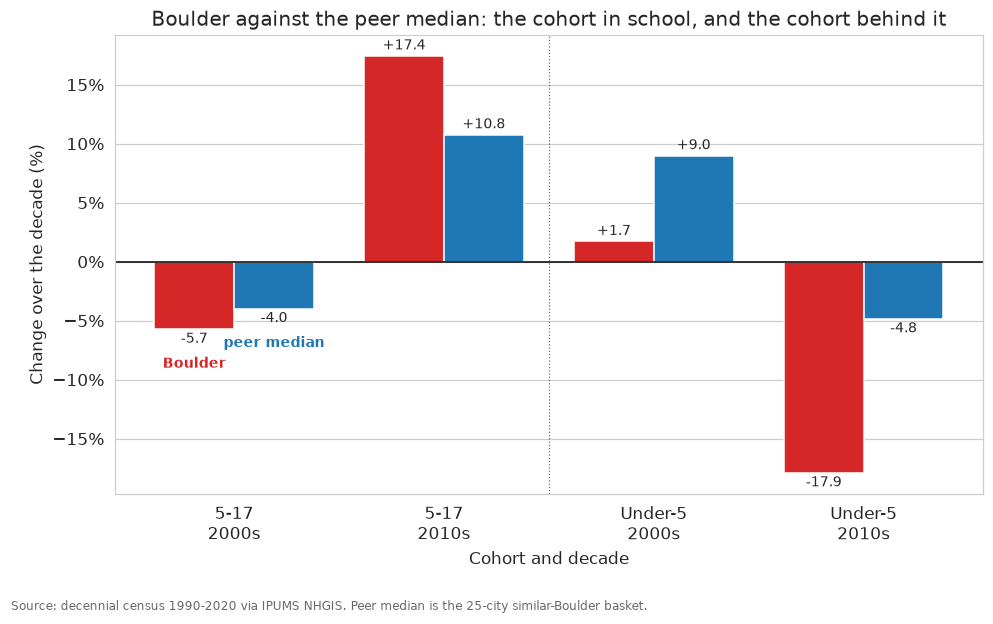

In [9]:
# The two cohorts pull apart in the 2010s: Boulder beats the peer median on the children already
# in school and loses badly on the children behind them.
cohort_groups_l = ['5-17\n2000s', '5-17\n2010s', 'Under-5\n2000s', 'Under-5\n2010s']
boulder_vals_l = [boulder_s.sa_chg_00_10, boulder_sa_chg_10_20,
                boulder_s.u5_chg_00_10, boulder_u5_chg_10_20]
peer_vals_l = [peers_df.sa_chg_00_10.median(), peer_sa_chg_10_20,
             peers_df.u5_chg_00_10.median(), peer_u5_chg_10_20]

f, ax = plt.subplots(figsize=(9, 5.4))
x = np.arange(len(cohort_groups_l)); width = 0.38
bars_boulder = ax.bar(x - width / 2, boulder_vals_l, width, color=BOULDER_C)
bars_peer = ax.bar(x + width / 2, peer_vals_l, width, color=PEER_C)
ax.bar_label(bars_boulder, fmt='%+.1f', fontsize=9, padding=2)
ax.bar_label(bars_peer, fmt='%+.1f', fontsize=9, padding=2)

# Identify the two series on the leftmost group only
for value, offset, label, color in [(boulder_vals_l[0], -width / 2, 'Boulder', BOULDER_C),
                                    (peer_vals_l[0], width / 2, 'peer median', PEER_C)]:
    ax.annotate(label, (x[0] + offset, value), color=color, fontweight='bold', fontsize=9,
                ha='center', va='top' if value < 0 else 'bottom',
                xytext=(0, -18 if value < 0 else 18), textcoords='offset points')

ax.axhline(0, color='k', lw=1)
ax.axvline(1.5, color='dimgray', lw=0.8, ls=':')     # divides the two cohorts
ax.set_xticks(x); ax.set_xticklabels(cohort_groups_l)
ax.set_xlabel('Cohort and decade')
ax.set_ylabel('Change over the decade (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title('Boulder against the peer median: the cohort in school, and the cohort behind it')
ax.grid(axis='x', visible=False)
f.text(0, -0.04, 'Source: decennial census 1990-2020 via IPUMS NHGIS. Peer median is the 25-city '
                 'similar-Boulder basket.', fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig1-peer-cohorts.png', bbox_inches='tight')

Those four numbers are a slice of a wider profile. Running the same comparison across the whole
age range shows where else the two diverge, and it turns up an age group the school debate rarely
mentions.

The buckets below follow the shape of the question rather than a fixed width: 10-17 is roughly
middle and high school, 18-24 is the college years, and 25-34 and 35-44 split the ages at which
people are most likely to be raising children. Each one is an exact sum of rows the source
publishes, including the 15-17 and 18-19 rows that let 10-17 and 18-24 be cut where they are, and
together they account for the whole population with nothing left over.

A third series gives the national baseline. The peer basket holds 25 college towns, which share a
shape no national figure has, so a gap against the peer median and a gap against the country say
different things: the first asks whether Boulder is unusual among towns like it, the second whether
the towns like it are unusual. The national counts come from the same censuses,
[table P12](https://www.census.gov/data/developers/data-sets/decennial-census.html), whose
published rows cut at the same ages the peer buckets use.

In [10]:
national_age_groups_df = pd.read_csv(PROC / 'national-age-groups.csv')
national_age_groups_d = {year: frame for year, frame in national_age_groups_df.groupby('year')}

# Integrity checks
assert set(national_age_groups_d) == {2010, 2020}, 'expected both censuses'
for year, groups_df in national_age_groups_d.items():
    assert groups_df['pop'].gt(0).all(), f'{year}: non-positive count'
    assert groups_df['age_lo'].is_monotonic_increasing, f'{year}: age rows out of order'

print('National population by P12 age row:')
for year, groups_df in national_age_groups_d.items():
    print(f'  {year}: {len(groups_df)} age rows, {groups_df["pop"].sum():,.0f} people')

National population by P12 age row:
  2010: 23 age rows, 308,745,538 people
  2020: 23 age rows, 331,449,281 people


### Ten buckets, three series

Each bucket is checked to be an exact sum of published rows that tiles the whole population, for
every place and for the nation, before any change is computed.

In [11]:
# Buckets chosen for the question, each an exact sum of published rows
AGE_BUCKETS = [('0-4', 0, 4), ('5-9', 5, 9), ('10-17', 10, 17), ('18-24', 18, 24),
               ('25-34', 25, 34), ('35-44', 35, 44), ('45-54', 45, 54), ('55-64', 55, 64),
               ('65-74', 65, 74), ('75+', 75, 999)]
SCHOOL_AGE_BUCKETS = 3          # 0-4, 5-9 and 10-17 are the ages that feed the schools

def bucket_population(fips, year):
    rows = place_age_groups_df[(place_age_groups_df['place_fips'] == fips)
                               & (place_age_groups_df['year'] == year)]
    counts = {}
    for label, lo, hi in AGE_BUCKETS:
        band = rows[(rows['age_lo'] >= lo) & (rows['age_hi'] <= hi)]
        assert not band.empty, f'{label} matched no published row'
        counts[label] = band['pop'].sum()
    # the buckets must account for everyone, or the chart is quietly dropping people
    assert abs(sum(counts.values()) - rows['pop'].sum()) < 1e-6, f'{fips} {year}: buckets do not tile'
    return counts

def bucket_rows(groups_df):
    # The same bucketing rule the places use, applied to any table of published age rows
    counts = {}
    for label, lo, hi in AGE_BUCKETS:
        band = groups_df[(groups_df['age_lo'] >= lo) & (groups_df['age_hi'] <= hi)]
        assert not band.empty, f'{label} matched no published row'
        counts[label] = band['pop'].sum()
    assert abs(sum(counts.values()) - groups_df['pop'].sum()) < 1e-6, 'buckets do not tile'
    return counts

def pct_change(first, last):
    return {label: (last[label] / first[label] - 1) * 100 for label in first}

def bucket_pct_change(fips, start=2010, end=2020):
    return pct_change(bucket_population(fips, start), bucket_population(fips, end))

national_change_d = pct_change(bucket_rows(national_age_groups_d[2010]),
                               bucket_rows(national_age_groups_d[2020]))

profile_df = pd.DataFrame({'Boulder': pd.Series(bucket_pct_change(BOULDER)),
                           'peer_median': pd.DataFrame([bucket_pct_change(f) for f in PEER_FIPS]).median(),
                           'national': pd.Series(national_change_d)})
profile_df = profile_df.loc[[b[0] for b in AGE_BUCKETS]]
profile_df.index.name = 'age_bucket'
profile_df['gap_points'] = profile_df['Boulder'] - profile_df['peer_median']
profile_df['gap_national'] = profile_df['Boulder'] - profile_df['national']

assert profile_df.notna().all().all(), 'an age bucket produced no value'

In [12]:
worst_bucket, best_bucket = profile_df['gap_points'].idxmin(), profile_df['gap_points'].idxmax()
print('Change 2010 to 2020 by age bucket, Boulder against the peer median:')
print(f"  widest shortfall at {worst_bucket}: {profile_df.loc[worst_bucket, 'Boulder']:+.1f}% against "
      f"{profile_df.loc[worst_bucket, 'peer_median']:+.1f}%, a gap of {profile_df.loc[worst_bucket, 'gap_points']:+.1f} points")
print(f"  widest lead at {best_bucket}: {profile_df.loc[best_bucket, 'Boulder']:+.1f}% against "
      f"{profile_df.loc[best_bucket, 'peer_median']:+.1f}%, a gap of {profile_df.loc[best_bucket, 'gap_points']:+.1f} points")
print(f"  Boulder beats the peer median in {int((profile_df.gap_points > 0).sum())} of {len(profile_df)} buckets, "
      f"and the national rate in {int((profile_df.gap_national > 0).sum())} of {len(profile_df)}")
school_age_l = [b[0] for b in AGE_BUCKETS[:SCHOOL_AGE_BUCKETS]]
print('\nThe ages that feed the schools, all three series:')
for label in school_age_l:
    row = profile_df.loc[label]
    print(f"  {label:>5}: Boulder {row.Boulder:+6.1f}%   peers {row.peer_median:+6.1f}%   "
          f"nation {row.national:+6.1f}%")
profile_df.round(1)

Change 2010 to 2020 by age bucket, Boulder against the peer median:
  widest shortfall at 35-44: -1.0% against +14.5%, a gap of -15.5 points
  widest lead at 65-74: +86.0% against +61.2%, a gap of +24.8 points
  Boulder beats the peer median in 6 of 10 buckets, and the national rate in 7 of 10

The ages that feed the schools, all three series:
    0-4: Boulder  -17.9%   peers   -4.8%   nation   -8.9%
    5-9: Boulder   -0.5%   peers   +6.7%   nation   -1.1%
  10-17: Boulder  +29.6%   peers  +15.1%   nation   +2.8%


,Boulder,peer_median,national,gap_points,gap_national
age_bucket,,,,,
0-4,-17.9,-4.8,-8.9,-13.1,-9.0
5-9,-0.5,6.7,-1.1,-7.2,0.6
10-17,29.6,15.1,2.8,14.5,26.8
18-24,2.3,1.3,1.9,1.1,0.4
25-34,19.4,16.0,9.2,3.3,10.2
35-44,-1.0,14.5,2.7,-15.5,-3.7
45-54,5.3,-3.1,-9.2,8.5,14.5
55-64,5.2,10.0,19.0,-4.7,-13.7
65-74,86.0,61.2,52.5,24.8,33.5


The chart names the three series once, over the leftmost group, in the order the bars keep in
every group, and prints every value.

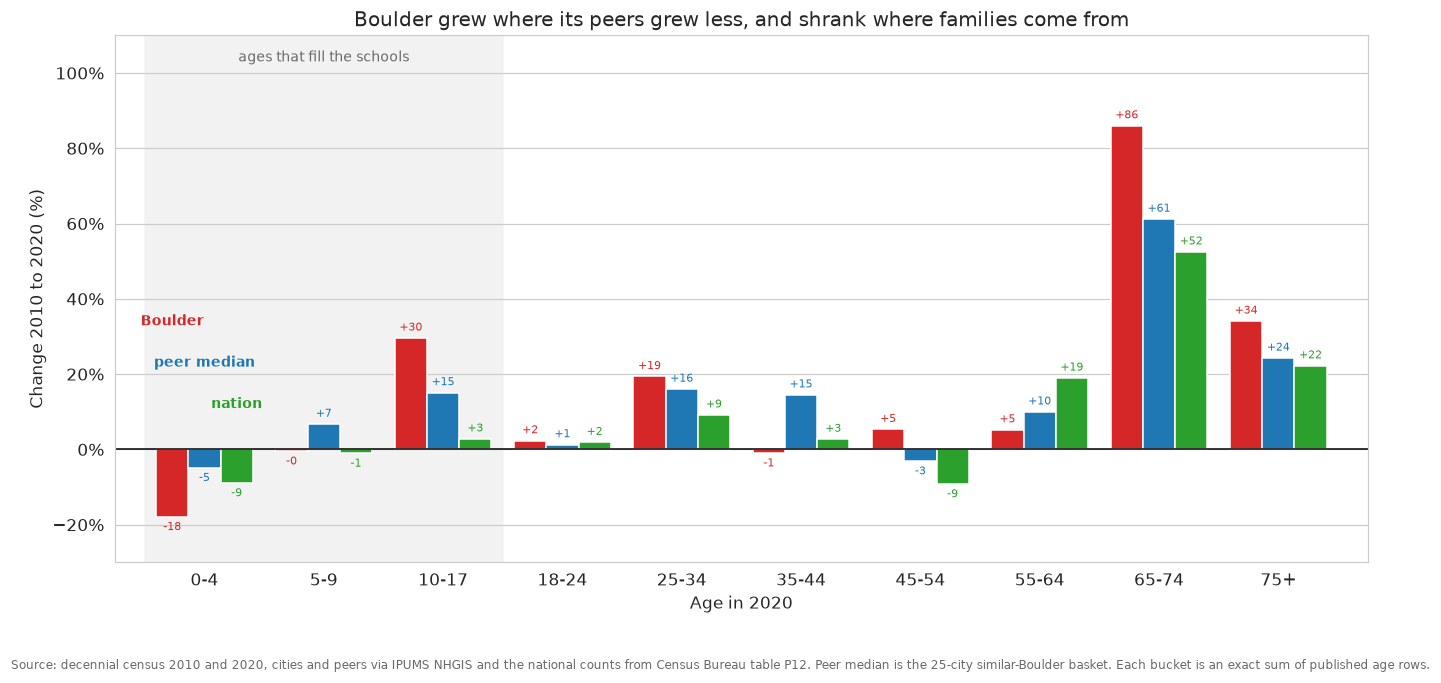

In [13]:
SERIES = [('Boulder', BOULDER_C), ('peer_median', PEER_C), ('national', NATION_C)]
SERIES_LABELS = {'Boulder': 'Boulder', 'peer_median': 'peer median', 'national': 'nation'}

f, ax = plt.subplots(figsize=(12.5, 5.8))
x = np.arange(len(profile_df)); width = 0.27
for position, (column, color) in enumerate(SERIES):
    bars = ax.bar(x + (position - 1) * width, profile_df[column], width, color=color)
    # 5-9 and 35-44 barely moved, so the bar alone shows nothing; label every value
    ax.bar_label(bars, fmt='%+.0f', fontsize=7.5, padding=3, color=color)

ax.axvspan(-0.5, SCHOOL_AGE_BUCKETS - 0.5, color='#f2f2f2', zorder=0)
ax.text((SCHOOL_AGE_BUCKETS - 1) / 2, profile_df[[s for s, _ in SERIES]].max().max() + 20,
        'ages that fill the schools', fontsize=9, color='dimgray', ha='center', va='top')

# name the three series over the 0-4 group, where every bar points down and the space above is
# empty; they read left to right in the same order as the bars in every group
for position, (column, color) in enumerate(SERIES):
    ax.annotate(SERIES_LABELS[column], (x[0] + (position - 1) * width, 34 - position * 11),
                color=color, fontweight='bold', fontsize=9, ha='center', va='center')

ax.axhline(0, color='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(profile_df.index)
ax.set_xlim(-0.75, len(profile_df) - 0.25)
ax.set_ylim(profile_df[[s for s, _ in SERIES]].min().min() - 12,
            profile_df[[s for s, _ in SERIES]].max().max() + 24)
ax.set_ylabel('Change 2010 to 2020 (%)')
ax.set_xlabel('Age in 2020')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title('Boulder grew where its peers grew less, and shrank where families come from')
ax.grid(axis='x', visible=False)
f.text(0, -0.06, 'Source: decennial census 2010 and 2020, cities and peers via IPUMS NHGIS and the '
                 'national counts from Census Bureau table P12. Peer median is the 25-city '
                 'similar-Boulder basket. Each bucket is an exact sum of published age rows.',
       fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig2-age-profile.png', bbox_inches='tight')

### What the state's own forecast says, by age

Everything above is a count, and it stops in 2020. This asks what the Colorado State Demography
Office expects next: over the 2020 to 2050 window, does it expect Boulder County to move
differently from the region it sits in?

Two things keep this chart cheap to read. It uses one source, so no rate is chained across two, and
because the SDO publishes single years of age the ten buckets from the city figure come back
exactly. The unit changes, though, and that costs something: this is Boulder **County**, not the
City of Boulder, and the county is about three times the city.

The comparison group is the
[Front Range Urban Corridor](https://en.wikipedia.org/wiki/Front_Range_Urban_Corridor) as Wikipedia
defines it, less Boulder County itself and less the six counties under 50,000 residents. In a
county of six thousand people a single age bucket can swing tens of points on a few hundred
residents, which would move a median of sixteen without telling anyone anything. The full county
table is printed below, so any county's own numbers stay visible rather than buried in the median.

The third series is the Colorado row the SDO publishes with Boulder County subtracted from it. The
subtraction matters more than it looks: Boulder is 5.7% of the state and its own forecast runs the
other way from the state's, so leaving it in would have Boulder pulling down the line it is being
measured against. No series in this chart contains Boulder twice.

In [14]:
FRONT_RANGE_MIN_POP = 50_000    # below this a single bucket swings on a few hundred people
SDO_START, SDO_END = 2020, 2050

# The ten buckets from the city figure. The SDO publishes single years of age, so each is exact.
def sdo_bucket_population(frame, year):
    rows = frame[frame['year'] == year]
    counts = {}
    for label, lo, hi in AGE_BUCKETS:
        counts[label] = rows.loc[rows['age'].between(lo, hi), 'totalpopulation'].sum()
    assert abs(sum(counts.values()) - rows['totalpopulation'].sum()) < 1e-6, 'buckets do not tile'
    return counts

def sdo_bucket_change(frame, start=SDO_START, end=SDO_END):
    first, last = sdo_bucket_population(frame, start), sdo_bucket_population(frame, end)
    return {label: (last[label] / first[label] - 1) * 100 for label in first}

# Colorado with Boulder County taken out, so the state series is not partly the county it is
# being compared against. The published state row is the base; Boulder is subtracted from it
# age by age and year by year rather than the counties being re-summed.
state_age_s = (sya_df.loc[sya_df['countyfips'] == COLORADO_CODE]
               .set_index(['year', 'age'])['totalpopulation'])
boulder_age_s = (sya_df.loc[sya_df['county'] == 'Boulder']
                 .set_index(['year', 'age'])['totalpopulation'])
assert state_age_s.index.equals(boulder_age_s.index), 'the state and Boulder ladders do not line up'
colorado_ex_boulder_df = (state_age_s - boulder_age_s).rename('totalpopulation').reset_index()
assert colorado_ex_boulder_df['totalpopulation'].gt(0).all(), 'Boulder exceeds the state in some cell'

front_range_pop_s = (sya_df.loc[(sya_df['year'] == SDO_START) & (sya_df['countyfips'] != COLORADO_CODE)]
                     .groupby('county')['totalpopulation'].sum().sort_values(ascending=False))
c0 = front_range_pop_s >= FRONT_RANGE_MIN_POP
comparison_counties_l = [name for name in front_range_pop_s[c0].index if name != 'Boulder']
dropped_counties_l = list(front_range_pop_s[~c0].index)

assert 'Boulder' not in comparison_counties_l, 'Boulder is in its own comparison group'
assert len(comparison_counties_l) + len(dropped_counties_l) + 1 == len(front_range_pop_s), \
    'a Front Range county is in neither group'

print(f'Front Range Urban Corridor: {len(front_range_pop_s)} Colorado counties')
print(f'  comparison group ({len(comparison_counties_l)}, at or above {FRONT_RANGE_MIN_POP:,} in {SDO_START}): '
      f"{', '.join(comparison_counties_l)}")
print(f"  below the threshold and dropped: {', '.join(dropped_counties_l)}")
print(f"  Boulder County itself sits {int(front_range_pop_s.rank(ascending=False)['Boulder'])}th of "
      f'{len(front_range_pop_s)} by {SDO_START} population')
front_range_pop_s.to_frame(f'{SDO_START} population').round(0)

Front Range Urban Corridor: 17 Colorado counties
  comparison group (10, at or above 50,000 in 2020): El Paso, Denver, Arapahoe, Jefferson, Adams, Douglas, Larimer, Weld, Pueblo, Broomfield
  below the threshold and dropped: Fremont, Elbert, Teller, Park, Clear Creek, Gilpin
  Boulder County itself sits 9th of 17 by 2020 population


,2020 population
county,
El Paso,733829
Denver,717621
Arapahoe,655287
Jefferson,583137
Adams,520490
Douglas,360317
Larimer,359959
Weld,331458
Boulder,330952


Each comparison county gets one row, so the median is a number a reader can check against the
counties behind it. The table after the summary prints every one of them.

In [15]:
# Every Front Range county in the comparison group, one row each, so the median is inspectable
front_range_change_df = pd.DataFrame(
    {name: sdo_bucket_change(sya_df[sya_df['county'] == name]) for name in comparison_counties_l}
).T.loc[comparison_counties_l, [label for label, _, _ in AGE_BUCKETS]]

sdo_profile_df = pd.DataFrame({
    'Boulder': pd.Series(sdo_bucket_change(sya_df[sya_df['county'] == 'Boulder'])),
    'front_range_median': front_range_change_df.median(),
    'colorado_ex_boulder': pd.Series(sdo_bucket_change(colorado_ex_boulder_df))
}).loc[[label for label, _, _ in AGE_BUCKETS]]
sdo_profile_df.index.name = 'age_bucket'
sdo_profile_df['gap_points'] = sdo_profile_df['Boulder'] - sdo_profile_df['front_range_median']

# Integrity checks
assert sdo_profile_df.notna().all().all(), 'a bucket produced no value'
assert len(front_range_change_df) == len(comparison_counties_l), 'a comparison county is missing'
# Boulder's own numbers must not come from the comparison group
assert 'Boulder' not in front_range_change_df.index, 'Boulder leaked into the median'

sdo_worst = sdo_profile_df['gap_points'].idxmin()
sdo_best = sdo_profile_df['gap_points'].idxmax()
school_age_l = [label for label, _, _ in AGE_BUCKETS[:SCHOOL_AGE_BUCKETS]]
print(f'Colorado SDO, {SDO_START} to {SDO_END}, Boulder County against the Front Range median:')
print(f"  widest shortfall at {sdo_worst}: {sdo_profile_df.loc[sdo_worst, 'Boulder']:+.1f}% against "
      f"{sdo_profile_df.loc[sdo_worst, 'front_range_median']:+.1f}%, a gap of "
      f"{sdo_profile_df.loc[sdo_worst, 'gap_points']:+.1f} points")
print(f"  widest lead at {sdo_best}: {sdo_profile_df.loc[sdo_best, 'Boulder']:+.1f}% against "
      f"{sdo_profile_df.loc[sdo_best, 'front_range_median']:+.1f}%, a gap of "
      f"{sdo_profile_df.loc[sdo_best, 'gap_points']:+.1f} points")
print(f"  Boulder beats the Front Range median in {int((sdo_profile_df.gap_points > 0).sum())} of "
      f'{len(sdo_profile_df)} buckets, and Colorado without Boulder in '
      f"{int((sdo_profile_df.Boulder > sdo_profile_df.colorado_ex_boulder).sum())} of {len(sdo_profile_df)}")
print(f"\nThe ages that feed the schools ({', '.join(school_age_l)}):")
for label in school_age_l:
    row = sdo_profile_df.loc[label]
    print(f'  {label:>5}: Boulder {row.Boulder:+6.1f}%   Front Range {row.front_range_median:+6.1f}%   '
          f'Colorado less Boulder {row.colorado_ex_boulder:+6.1f}%')
sdo_profile_df.round(1)

Colorado SDO, 2020 to 2050, Boulder County against the Front Range median:
  widest shortfall at 55-64: -2.3% against +40.6%, a gap of -42.9 points
  widest lead at 75+: +161.8% against +145.4%, a gap of +16.4 points
  Boulder beats the Front Range median in 1 of 10 buckets, and Colorado without Boulder in 2 of 10

The ages that feed the schools (0-4, 5-9, 10-17):
    0-4: Boulder   +3.7%   Front Range   +5.1%   Colorado less Boulder   +1.4%
    5-9: Boulder   -7.8%   Front Range   +6.0%   Colorado less Boulder   +2.3%
  10-17: Boulder  -17.2%   Front Range   +3.6%   Colorado less Boulder   -0.6%


,Boulder,front_range_median,colorado_ex_boulder,gap_points
age_bucket,,,,
0-4,3.7,5.1,1.4,-1.4
5-9,-7.8,6.0,2.3,-13.8
10-17,-17.2,3.6,-0.6,-20.9
18-24,-9.0,12.6,7.4,-21.6
25-34,-9.9,15.5,7.1,-25.4
35-44,11.3,33.7,31.7,-22.4
45-54,6.7,45.3,42.9,-38.6
55-64,-2.3,40.6,29.0,-42.9
65-74,22.8,34.6,30.9,-11.8


In [16]:
# Every county behind the median, printed rather than summarised
front_range_display_df = front_range_change_df.copy()
front_range_display_df.loc['— median —'] = front_range_change_df.median()
front_range_display_df.loc['— Boulder County —'] = sdo_profile_df['Boulder']
front_range_display_df.loc['— Colorado less Boulder —'] = sdo_profile_df['colorado_ex_boulder']
print(f'Change {SDO_START} to {SDO_END} by age bucket, every Front Range county in the group (%):')
front_range_display_df.round(1)

Change 2020 to 2050 by age bucket, every Front Range county in the group (%):


,0-4,5-9,10-17,18-24,25-34,35-44,45-54,55-64,65-74,75+
El Paso,4.6,6.4,3.7,14.1,18.9,62.0,73.5,30.9,16.1,88.8
Denver,-8.5,-7.1,-13.1,-4.2,-10.9,26.9,52.0,50.3,27.2,99.8
Arapahoe,11.9,8.5,-1.8,11.2,16.0,32.7,31.0,23.0,32.6,137.7
Jefferson,-5.2,-2.3,-8.8,1.4,-10.4,6.8,7.6,5.8,7.4,89.9
Adams,5.6,5.6,4.4,14.1,18.6,34.7,68.0,54.1,64.7,182.3
Douglas,15.8,12.0,9.6,27.8,40.7,46.8,38.6,50.7,89.7,362.2
Larimer,4.5,2.1,3.6,2.4,15.0,22.2,25.4,13.2,30.2,153.0
Weld,20.5,25.4,31.7,40.3,43.5,63.6,91.6,87.5,94.9,230.9
Pueblo,-48.8,-42.6,-34.9,-37.3,-46.4,-20.4,27.1,23.3,36.6,130.9
Broomfield,8.3,9.2,7.3,16.5,-3.8,46.3,61.6,94.0,74.5,206.9


The chart follows the city figure's layout, so the two read side by side.

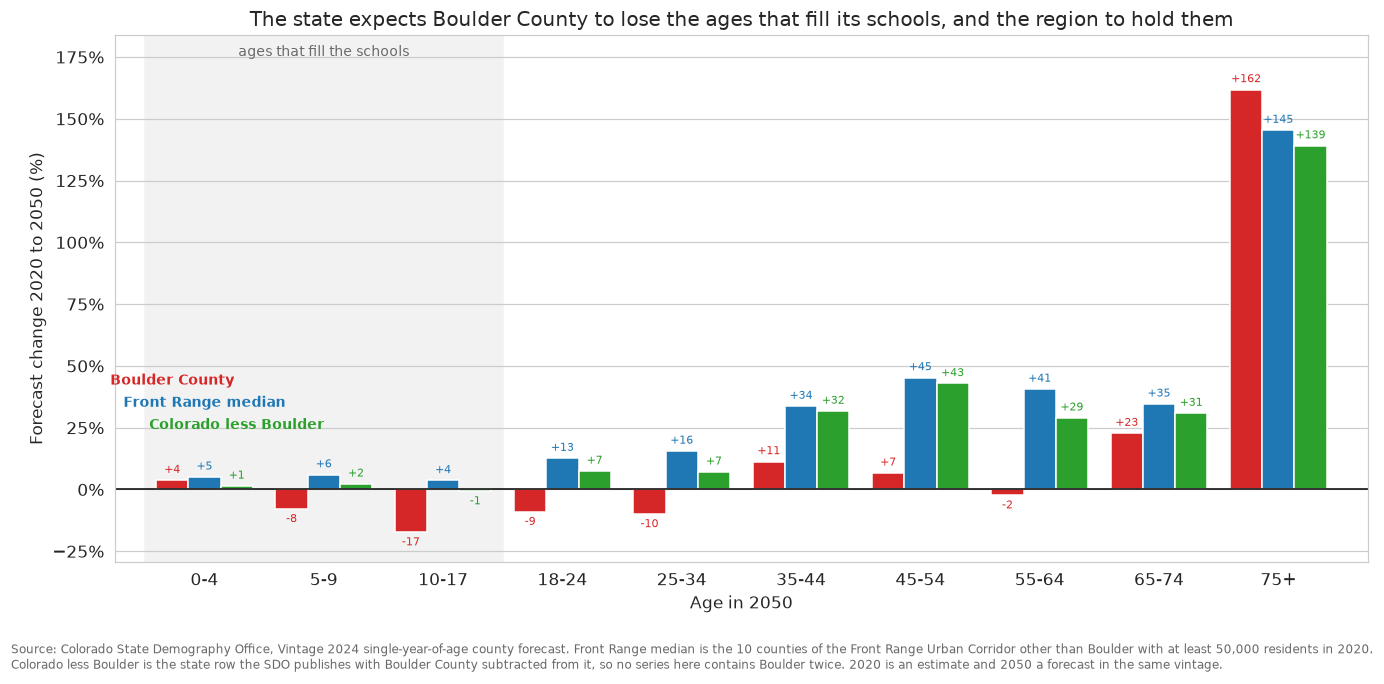

In [17]:
SDO_SERIES = [('Boulder', BOULDER_C, 'Boulder County'),
              ('front_range_median', PEER_C, 'Front Range median'),
              ('colorado_ex_boulder', NATION_C, 'Colorado less Boulder')]

f, ax = plt.subplots(figsize=(12.5, 5.8))
x = np.arange(len(sdo_profile_df)); width = 0.27
for position, (column, color, _) in enumerate(SDO_SERIES):
    bars = ax.bar(x + (position - 1) * width, sdo_profile_df[column], width, color=color)
    ax.bar_label(bars, fmt='%+.0f', fontsize=7.5, padding=3, color=color)

ax.axvspan(-0.5, SCHOOL_AGE_BUCKETS - 0.5, color='#f2f2f2', zorder=0)
ax.text((SCHOOL_AGE_BUCKETS - 1) / 2,
        sdo_profile_df[[s for s, _, _ in SDO_SERIES]].max().max() + 18,
        'ages that fill the schools', fontsize=9, color='dimgray', ha='center', va='top')

# Name the three series over the leftmost bucket, in the same order as the bars in every group
for position, (column, color, label) in enumerate(SDO_SERIES):
    ax.annotate(label, (x[0] + (position - 1) * width, 44 - position * 9),
                color=color, fontweight='bold', fontsize=9, ha='center', va='center')

ax.axhline(0, color='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(sdo_profile_df.index)
ax.set_xlim(-0.75, len(sdo_profile_df) - 0.25)
ax.set_ylim(sdo_profile_df[[s for s, _, _ in SDO_SERIES]].min().min() - 12,
            sdo_profile_df[[s for s, _, _ in SDO_SERIES]].max().max() + 22)
ax.set_ylabel(f'Forecast change {SDO_START} to {SDO_END} (%)')
ax.set_xlabel(f'Age in {SDO_END}')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_title("The state expects Boulder County to lose the ages that fill its schools, "
             "and the region to hold them")
ax.grid(axis='x', visible=False)
f.text(0, -0.06, f'Source: Colorado State Demography Office, Vintage 2024 single-year-of-age county '
                 f'forecast. Front Range median is the {len(comparison_counties_l)} counties of the '
                 f'Front Range Urban Corridor other than Boulder with at least '
                 f'{FRONT_RANGE_MIN_POP:,} residents in {SDO_START}. Colorado less Boulder is the '
                 f'state row the SDO publishes with Boulder County subtracted from it, so no series '
                 f'here contains Boulder twice. {SDO_START} is an estimate and {SDO_END} a forecast '
                 f'in the same vintage.', fontsize=8, color='dimgray', wrap=True)
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig3-sdo-age-profile.png', bbox_inches='tight')

Read against the figure before it, this is the same question asked of the next thirty years, on a
larger unit and from a forecast rather than a count. The census had the City of Boulder gaining
school-age children through the 2010s while the cohort behind them fell; the state expects Boulder
County to lose all three of the buckets that feed its schools by 2050 while the Front Range holds
roughly steady, so the loss lands in exactly the ages the closure proposal is about. Neither
comparison series contains Boulder: it is out of the Front Range median and subtracted from the
state.

Two features of the chart are worth naming before anyone leans on it. The first is that the
comparison group is a region, not a set of matched places: Denver, Douglas and Weld are growing
from very different starting points and for very different reasons, and a median across them
describes the corridor rather than any city like Boulder. The second is that 2020 here is an
estimate and 2050 a forecast from the same vintage, so the window mixes a measured base with a
modelled end. That is how the SDO series is meant to be read, and its 2020 estimate for Boulder
County sits within a tenth of a percent of the census count, but it is not the same kind of number
at both ends.

The second measure is harder to explain away as a compositional accident. Apply each place's own
2010 child-per-adult ratios to its 2020 adult population, and compare the children it should have
had with the children it counted. This asks whether a place kept the families its own recent past
implies, holding its own fertility behaviour fixed.

In [18]:
# Children 0-9 in 2020 against what each place's own 2010 child ratios imply for its 2020 adults
FERT_0_4 = slice(G[15], G[40] + 1)   # residents 15-44 generate the 0-4 cohort
FERT_5_9 = slice(G[20], G[45] + 1)   # residents 20-49 generate the 5-9 cohort

def child_ratios(vec):
    return vec[G[0]] / vec[FERT_0_4].sum(), vec[G[5]] / vec[FERT_5_9].sum()

records_l = []
for fips in places_df['place_fips']:
    vec_2010, _ = place_age_d[fips][2010]
    vec_2020, _ = place_age_d[fips][2020]
    r0, r5 = child_ratios(vec_2010)
    implied = r0 * vec_2020[FERT_0_4].sum() + r5 * vec_2020[FERT_5_9].sum()
    actual = vec_2020[G[0]] + vec_2020[G[5]]
    records_l.append({'place_fips': fips, 'name': place_name_s[fips],
                    'implied_0_9': implied, 'actual_0_9': actual,
                    'gap_pct': (actual / implied - 1) * 100})
implied_df = pd.DataFrame(records_l).set_index('place_fips')

boulder_implied_gap = implied_df.loc[BOULDER, 'gap_pct']
implied_steeper_pct = pct_steeper_than(implied_df.loc[PEER_FIPS, 'gap_pct'], boulder_implied_gap)
print('Children 0-9 in 2020 vs what each place\'s own 2010 child ratios imply')
print(f'  Boulder {boulder_implied_gap:+.1f}%   peer median {implied_df.loc[PEER_FIPS, "gap_pct"].median():+.1f}%')
print(f'  more negative than {implied_steeper_pct:.0f}% of peers')
implied_df.loc[[BOULDER] + PEER_FIPS].sort_values('gap_pct')[['name', 'implied_0_9', 'actual_0_9', 'gap_pct']].round(1).head(10)

Children 0-9 in 2020 vs what each place's own 2010 child ratios imply
  Boulder -14.7%   peer median -9.7%
  more negative than 92% of peers


,name,implied_0_9,actual_0_9,gap_pct
place_fips,,,,
0656000,Pasadena,14857.0,12458.0,-16.1
2754880,Rochester,18300.9,15598.0,-14.8
0807850,Boulder,8321.9,7095.0,-14.7
0827425,Fort Collins,18917.2,16232.0,-14.2
3719000,Durham,38434.1,33051.0,-14.0
4261000,Pittsburgh,29740.9,25620.0,-13.9
0669070,Santa Barbara,8761.1,7733.0,-11.7
0649670,Mountain View,10583.7,9359.0,-11.6
1724582,Evanston,8200.6,7255.0,-11.5


Dividing both counts by the same 2020 adult base turns the comparison into a rate every city can
be read on: children aged 0-9 per 1,000 residents aged 15-49. The first bar applies each place's
own 2010 child ratios to its 2020 adults, the second is what it actually counted, and the distance
between them is the shortfall above.

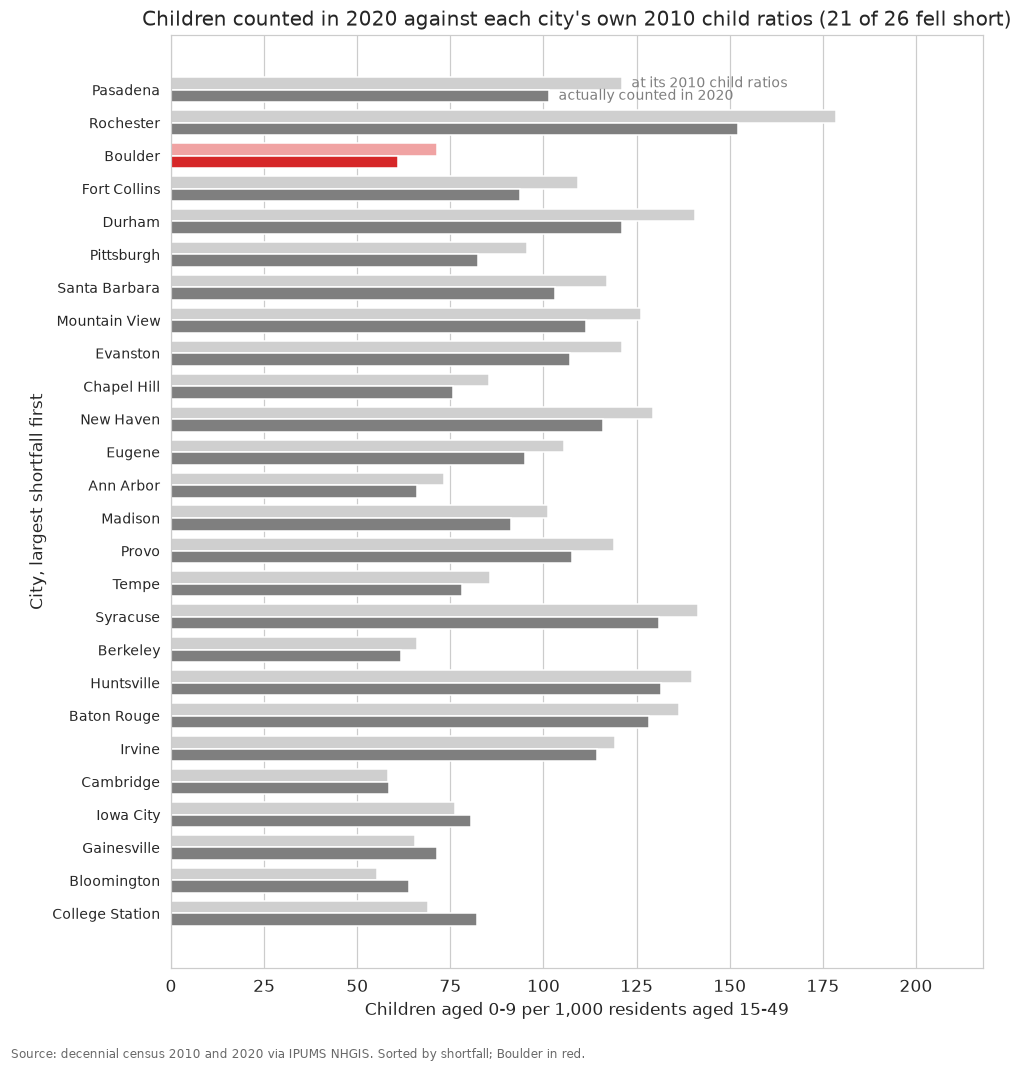

In [19]:
records_l = []
for fips in [BOULDER] + PEER_FIPS:
    vec_2010, _ = place_age_d[fips][2010]
    vec_2020, _ = place_age_d[fips][2020]
    r0, r5 = child_ratios(vec_2010)
    adult_base = vec_2020[FERT_0_4].sum() + vec_2020[FERT_5_9].sum()
    implied = r0 * vec_2020[FERT_0_4].sum() + r5 * vec_2020[FERT_5_9].sum()
    actual = vec_2020[G[0]] + vec_2020[G[5]]
    records_l.append({'name': place_name_s[fips], 'at_2010_ratios': implied / adult_base * 1000,
                    'actual_2020': actual / adult_base * 1000, 'gap_pct': (actual / implied - 1) * 100})
child_rate_df = pd.DataFrame(records_l).set_index('name').sort_values('gap_pct')

# both bars share a denominator, so their distance is the same shortfall the cell reports
assert np.allclose(child_rate_df['actual_2020'] / child_rate_df['at_2010_ratios'] - 1,
                   child_rate_df['gap_pct'] / 100), 'rates disagree with the reported gap'

IMPLIED_GREY, ACTUAL_GREY = '#cfcfcf', '#7f7f7f'
IMPLIED_RED, ACTUAL_RED = '#f0a3a3', HP_COLOR
is_boulder_arr = (child_rate_df.index == 'Boulder')

f, ax = plt.subplots(figsize=(9, 9.5))
y = np.arange(len(child_rate_df)); height = 0.38
ax.barh(y - height / 2, child_rate_df['at_2010_ratios'], height,
        color=np.where(is_boulder_arr, IMPLIED_RED, IMPLIED_GREY))
ax.barh(y + height / 2, child_rate_df['actual_2020'], height,
        color=np.where(is_boulder_arr, ACTUAL_RED, ACTUAL_GREY))

# Identify the two series on the topmost city only. Row 0 sits at the top once the axis
# is inverted below, so the labels go on row 0.
for column, offset, label in [('at_2010_ratios', -height / 2, 'at its 2010 child ratios'),
                              ('actual_2020', height / 2, 'actually counted in 2020')]:
    ax.annotate(label, (child_rate_df[column].iloc[0], y[0] + offset), color=ACTUAL_GREY, fontsize=9,
                va='center', xytext=(6, 0), textcoords='offset points')

ax.set_yticks(y); ax.set_yticklabels(child_rate_df.index, fontsize=9)
ax.invert_yaxis()                                  # largest shortfall at the top
ax.set_xlabel('Children aged 0-9 per 1,000 residents aged 15-49')
ax.set_ylabel('City, largest shortfall first')
ax.set_xlim(0, child_rate_df[['at_2010_ratios', 'actual_2020']].to_numpy().max() * 1.22)
n_short = int((child_rate_df['gap_pct'] < 0).sum())
ax.set_title(f"Children counted in 2020 against each city's own 2010 child ratios "
             f"({n_short} of {len(child_rate_df)} fell short)")
ax.grid(axis='y', visible=False)
f.text(0, -0.02, 'Source: decennial census 2010 and 2020 via IPUMS NHGIS. Sorted by shortfall; '
                 'Boulder in red.', fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig4-child-ratios.png', bbox_inches='tight')

The 2020 census counted children by single year of age, so the pipeline is visible directly. In
Boulder each younger cohort is smaller than the one above it. In Madison and Cambridge the
youngest cohort is the largest.

0-4 per 100 of the 10-14 cohort, 2020: {'Boulder': 72.0, 'Madison': 116.0, 'Cambridge': 142.0}


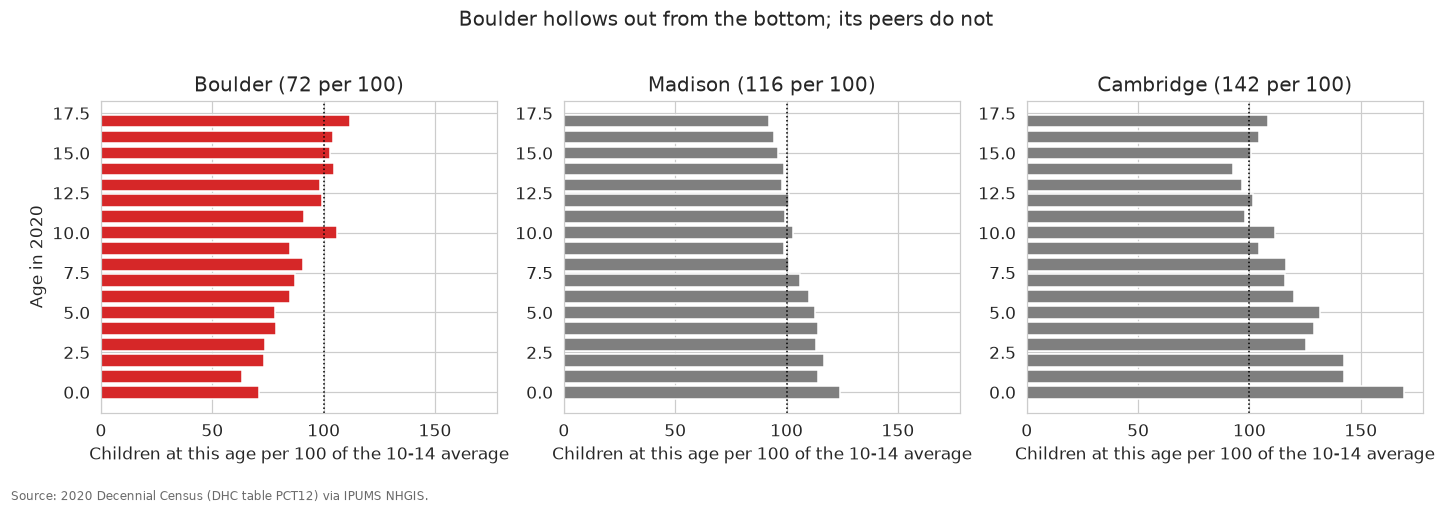

In [20]:
PYRAMID_PLACES = {'Boulder': '0807850', 'Madison': '5548000', 'Cambridge': '2511000'}
kids_2020_df = (place_age_single_df.loc[place_age_single_df['year'] == 2020]
                .pivot(index='age', columns='place_fips', values='pop'))
pyramid_df = pd.DataFrame({name: kids_2020_df[fips].loc[:17] for name, fips in PYRAMID_PLACES.items()})
pyramid_df.index.name = 'age'

# 0-4 per 100 of the 10-14 cohort: 100 means the pipeline is replacing itself
replacement_s = (pyramid_df.loc[0:4].sum() / pyramid_df.loc[10:14].sum() * 100).round(0)
boulder_replacement = replacement_s['Boulder']

f, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
for ax, city in zip(axes, PYRAMID_PLACES):
    indexed_s = pyramid_df[city] / pyramid_df[city].loc[10:14].mean() * 100
    ax.barh(pyramid_df.index, indexed_s, color=BOULDER_C if city == 'Boulder' else CONTEXT)
    ax.axvline(100, color='k', lw=1, ls=':')
    ax.set_title(f'{city} ({replacement_s[city]:.0f} per 100)')
    ax.set_xlabel('Children at this age per 100 of the 10-14 average')
axes[0].set_ylabel('Age in 2020')
f.suptitle('Boulder hollows out from the bottom; its peers do not', y=1.02)
f.text(0, -0.04, 'Source: 2020 Decennial Census (DHC table PCT12) via IPUMS NHGIS.', fontsize=8, color='dimgray')
plt.tight_layout()

print('0-4 per 100 of the 10-14 cohort, 2020:', replacement_s.to_dict())

That ratio generalizes. Reading it for every city in the basket at all three censuses turns each
pyramid into two points: how the ratio moved through the 2000s, and how it moved through the
2010s. Plotting the ratio at the start of a decade against the ratio at its end puts "no change"
on the diagonal, so a decade that added children sits above the line and a decade that lost them
sits below. Each arrow runs from a city's 2000s decade to its 2010s decade.

The geometry is worth reading twice, because it makes the arrow itself the finding. The tail sits
at (ratio in 2000, ratio in 2010) and the head at (ratio in 2010, ratio in 2020), so the arrow's
horizontal run is exactly what the city gained or lost through the 2000s, and its vertical drop is
exactly what it gained or lost through the 2010s. An arrow pointing right and down is a city that
was adding children and then stopped.

In [21]:
# Each city becomes an arrow: tail is the 2000s decade, head is the 2010s decade.
def pipeline_ratio(fips, year):
    vec, _ = place_age_d[fips][year]
    return vec[G[0]] / vec[G[10]] * 100

arrow_records_l = []
for fips in [BOULDER] + PEER_FIPS:
    r2000, r2010, r2020 = (pipeline_ratio(fips, y) for y in (2000, 2010, 2020))
    arrow_records_l.append({'name': place_name_s[fips], 'r2000': r2000, 'r2010': r2010, 'r2020': r2020,
                          'change_2000s': r2010 - r2000, 'change_2010s': r2020 - r2010})
arrows_df = pd.DataFrame(arrow_records_l).set_index('name')

REPLACEMENT = 100     # 100 children aged 0-4 per 100 aged 10-14 replaces the cohort
reversed_cities = int(((arrows_df.change_2000s > 0) & (arrows_df.change_2010s < 0)).sum())
crossed_down = int(((arrows_df.r2010 >= REPLACEMENT) & (arrows_df.r2020 < REPLACEMENT)).sum())
boulder_arrow_s = arrows_df.loc['Boulder']
print(f'{reversed_cities} of {len(arrows_df)} cities gained on this ratio through the 2000s and lost through the 2010s')
print(f'{crossed_down} fell from at-or-above {REPLACEMENT} in 2010 to below it in 2020')
print(f"Boulder: {boulder_arrow_s.r2000:.0f} (2000) -> {boulder_arrow_s.r2010:.0f} (2010) -> {boulder_arrow_s.r2020:.0f} (2020), "
      f'so {boulder_arrow_s.change_2000s:+.0f} then {boulder_arrow_s.change_2010s:+.0f}')
print(f"steeper 2010s fall than Boulder: "
      f"{', '.join(arrows_df.index[arrows_df.change_2010s < boulder_arrow_s.change_2010s])}")
arrows_df.round(0).sort_values('change_2010s')

23 of 26 cities gained on this ratio through the 2000s and lost through the 2010s
6 fell from at-or-above 100 in 2010 to below it in 2020
Boulder: 99 (2000) -> 111 (2010) -> 72 (2020), so +13 then -39
steeper 2010s fall than Boulder: Mountain View, Provo


,r2000,r2010,r2020,change_2000s,change_2010s
name,,,,,
Mountain View,136.0,162.0,117.0,26.0,-45.0
Provo,179.0,170.0,130.0,-9.0,-41.0
Boulder,99.0,111.0,72.0,13.0,-39.0
Evanston,106.0,116.0,76.0,10.0,-39.0
New Haven,100.0,120.0,87.0,20.0,-33.0
Durham,120.0,141.0,108.0,21.0,-32.0
Bloomington,133.0,140.0,109.0,8.0,-31.0
Fort Collins,96.0,108.0,81.0,12.0,-27.0
Rochester,103.0,128.0,102.0,25.0,-26.0


Boulder's arrow is drawn in red over the basket in gray, with the diagonal as the reference line.

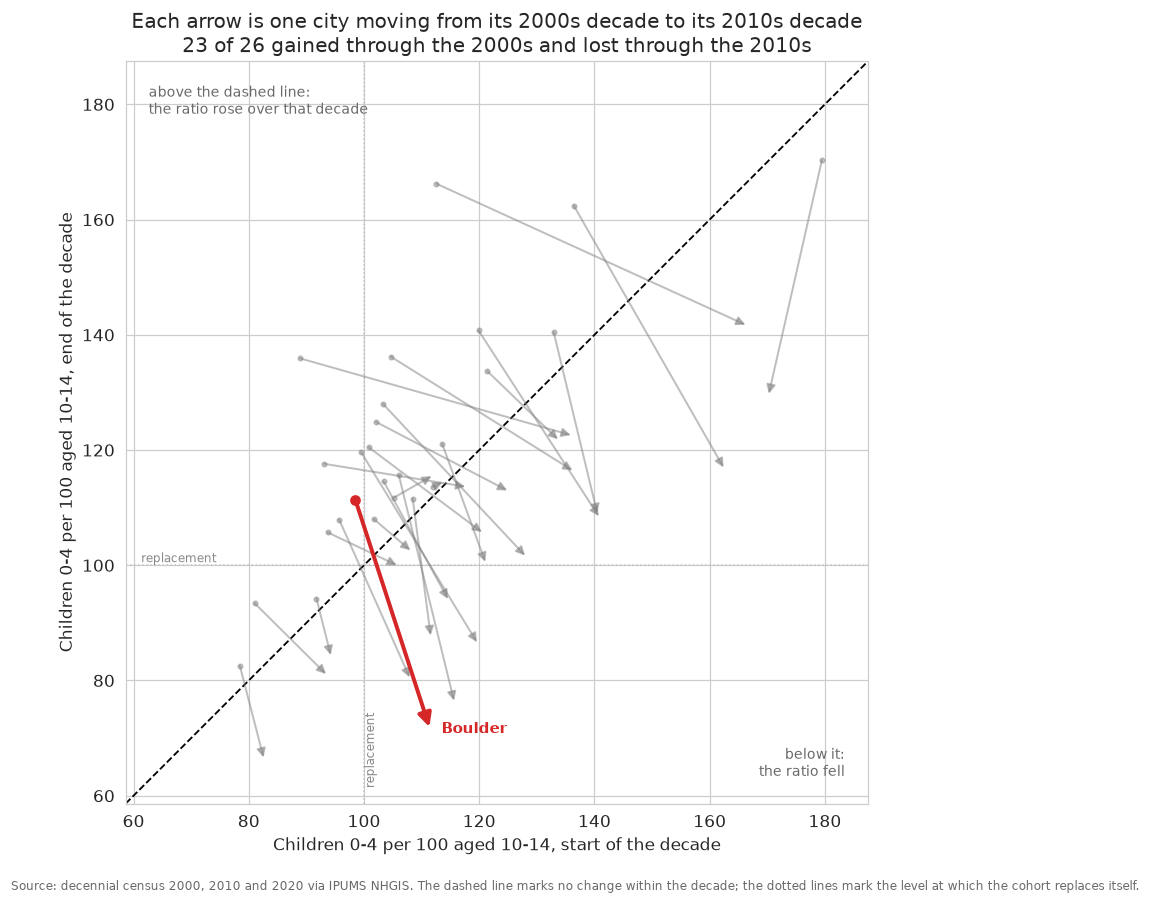

In [22]:
f, ax = plt.subplots(figsize=(8.4, 8))
lo = min(arrows_df[['r2000', 'r2010', 'r2020']].min()) - 8
hi = max(arrows_df[['r2000', 'r2010', 'r2020']].max()) + 8

# the diagonal is the reference the arrows are read against, so it is the darker line
ax.plot([lo, hi], [lo, hi], color='k', lw=1.2, ls='--', zorder=1)
for axis_line in (ax.axvline, ax.axhline):
    axis_line(REPLACEMENT, color='#c4c4c4', lw=1, ls=':', zorder=1)
ax.text(REPLACEMENT, lo + 2, ' replacement', fontsize=8, color='#8a8a8a', rotation=90, va='bottom')
ax.text(lo + 2, REPLACEMENT, ' replacement', fontsize=8, color='#8a8a8a', va='bottom')

for name, row in arrows_df.iterrows():
    is_boulder = name == 'Boulder'
    ax.annotate('', xy=(row.r2010, row.r2020), xytext=(row.r2000, row.r2010),
                arrowprops=dict(arrowstyle='-|>', color=HP_COLOR if is_boulder else CONTEXT,
                                lw=2.6 if is_boulder else 1.3,
                                alpha=1.0 if is_boulder else 0.5,
                                mutation_scale=18 if is_boulder else 12,
                                shrinkA=0, shrinkB=0), zorder=4 if is_boulder else 2)
    ax.plot(row.r2000, row.r2010, 'o', ms=6 if is_boulder else 3,
            color=HP_COLOR if is_boulder else CONTEXT,
            alpha=1.0 if is_boulder else 0.45, zorder=4 if is_boulder else 2)

ax.annotate('Boulder', (boulder_arrow_s.r2010, boulder_arrow_s.r2020), color=HP_COLOR, fontweight='bold',
            fontsize=10, xytext=(8, -4), textcoords='offset points')
ax.text(lo + 4, hi - 4, 'above the dashed line:\nthe ratio rose over that decade',
        fontsize=9, color='dimgray', va='top')
ax.text(hi - 4, lo + 4, 'below it:\nthe ratio fell', fontsize=9, color='dimgray',
        ha='right', va='bottom')

ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
ax.set_xlabel('Children 0-4 per 100 aged 10-14, start of the decade')
ax.set_ylabel('Children 0-4 per 100 aged 10-14, end of the decade')
ax.set_title(f'Each arrow is one city moving from its 2000s decade to its 2010s decade\n'
             f'{reversed_cities} of {len(arrows_df)} gained through the 2000s and lost through the 2010s')
f.text(0, -0.02, 'Source: decennial census 2000, 2010 and 2020 via IPUMS NHGIS. The dashed line marks no '
                 'change within the decade; the dotted lines mark the level at which the cohort replaces itself.',
       fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig5-pipeline-arrows.png', bbox_inches='tight')

The same arrows as a table, for redrawing the chart elsewhere. Each city is one arrow: it starts at
(2000 ratio, 2010 ratio) and ends at (2010 ratio, 2020 ratio), so a point above the diagonal rose
over that decade and a point below it fell. The wide table is one row per city and reads directly;
the long table is the same numbers with one row per arrow endpoint, which is the shape a connected
scatter plot wants.

In [23]:
# Arrow endpoints for redrawing the chart in another tool
arrow_coords_df = (arrows_df.reset_index()
                   .rename(columns={'name': 'city', 'r2000': 'x_start', 'r2010': 'y_start'})
                   .assign(x_end=lambda frame: frame['y_start'],
                           y_end=lambda frame: frame['r2020'],
                           series=lambda frame: np.where(frame['city'] == 'Boulder', 'Boulder', 'peer'))
                   [['city', 'series', 'x_start', 'y_start', 'x_end', 'y_end',
                     'change_2000s', 'change_2010s']]
                   .sort_values('change_2010s').reset_index(drop=True))

arrow_long_df = (arrow_coords_df
                 .melt(id_vars=['city', 'series'],
                       value_vars=['x_start', 'y_start', 'x_end', 'y_end'],
                       var_name='field', value_name='value')
                 .assign(point=lambda frame: frame['field'].str.split('_').str[1],
                         axis=lambda frame: frame['field'].str.split('_').str[0])
                 .pivot(index=['city', 'series', 'point'], columns='axis', values='value')
                 .reset_index().rename_axis(columns=None))
arrow_long_df['point_order'] = (arrow_long_df['point'] == 'end').astype(int) + 1
arrow_long_df = (arrow_long_df[['city', 'series', 'point', 'point_order', 'x', 'y']]
                 .sort_values(['city', 'point_order']).reset_index(drop=True))

# Integrity checks
assert len(arrow_coords_df) == len(arrows_df) == 26, 'a city is missing'
assert (arrow_coords_df['x_end'] == arrow_coords_df['y_start']).all(), \
    'the head must start where the tail ends: both are the 2010 ratio'
assert len(arrow_long_df) == 2 * len(arrow_coords_df), 'the long table is not two rows per city'
assert (arrow_coords_df['series'] == 'Boulder').sum() == 1, 'exactly one city is Boulder'

arrow_coords_df.round(1).to_csv(OUT / 'bvsd-fig5-pipeline-arrows.csv', index=False)
arrow_long_df.round(1).to_csv(OUT / 'bvsd-fig5-pipeline-arrows-long.csv', index=False)
print(f"wide: {OUT / 'bvsd-fig5-pipeline-arrows.csv'} · {len(arrow_coords_df)} rows, one per city")
print(f"long: {OUT / 'bvsd-fig5-pipeline-arrows-long.csv'} · {len(arrow_long_df)} rows, one per endpoint")
print('x and y are children aged 0-4 per 100 aged 10-14; start is the 2000s decade, end the 2010s.')

# The same two tables as plain text, to select and paste straight into Datawrapper's data box.
# A rendered DataFrame does not paste; comma-separated text does, and Datawrapper reads it.
for title, frame in [('LONG — one row per arrow endpoint, for a connected scatter plot', arrow_long_df),
                     ('WIDE — one row per city, both coordinate pairs', arrow_coords_df)]:
    print(f'\n{"=" * 78}\n{title}\n{"=" * 78}')
    print(frame.round(1).to_csv(index=False).strip())
arrow_coords_df.round(1)

wide: output/bvsd-fig5-pipeline-arrows.csv · 26 rows, one per city
long: output/bvsd-fig5-pipeline-arrows-long.csv · 52 rows, one per endpoint
x and y are children aged 0-4 per 100 aged 10-14; start is the 2000s decade, end the 2010s.

LONG — one row per arrow endpoint, for a connected scatter plot
city,series,point,point_order,x,y
Ann Arbor,peer,start,1,112.0,113.6
Ann Arbor,peer,end,2,113.6,114.4
Baton Rouge,peer,start,1,101.7,108.1
Baton Rouge,peer,end,2,108.1,102.6
Berkeley,peer,start,1,103.4,114.6
Berkeley,peer,end,2,114.6,94.1
Bloomington,peer,start,1,132.9,140.5
Bloomington,peer,end,2,140.5,109.0
Boulder,Boulder,start,1,98.5,111.3
Boulder,Boulder,end,2,111.3,71.9
Cambridge,peer,start,1,112.6,166.2
Cambridge,peer,end,2,166.2,141.7
Chapel Hill,peer,start,1,78.4,82.6
Chapel Hill,peer,end,2,82.6,66.6
College Station,peer,start,1,121.4,133.7
College Station,peer,end,2,133.7,121.8
Durham,peer,start,1,119.9,140.8
Durham,peer,end,2,140.8,108.5
Eugene,peer,start,1,91.8,94.2
Eugene,peer,e

,city,series,x_start,y_start,x_end,y_end,change_2000s,change_2010s
0,Mountain View,peer,136.4,162.4,162.4,117.0,26.0,-45.4
1,Provo,peer,179.5,170.3,170.3,129.8,-9.2,-40.5
2,Boulder,Boulder,98.5,111.3,111.3,71.9,12.8,-39.4
3,Evanston,peer,106.0,115.6,115.6,76.5,9.6,-39.1
4,New Haven,peer,99.5,119.6,119.6,86.6,20.1,-33.0
5,Durham,peer,119.9,140.8,140.8,108.5,20.9,-32.3
6,Bloomington,peer,132.9,140.5,140.5,109.0,7.6,-31.5
7,Fort Collins,peer,95.7,107.9,107.9,80.5,12.2,-27.4
8,Rochester,peer,103.3,128.0,128.0,101.7,24.6,-26.3
9,Cambridge,peer,112.6,166.2,166.2,141.7,53.6,-24.5


### Would an annual series say more?

Four decennial points invite an obvious objection: the under-5 finding might be an artifact of
which two census years got compared. The
[American Community Survey](https://www.census.gov/programs-surveys/acs) publishes annual estimates for
places above 65,000 residents, which covers the City of Boulder and three of its peers, so the
objection is testable.

`bvsd-retrieval.ipynb` has already pulled the annual estimate and its 90 percent margin of error
for Boulder and the three eligible peers. `B01001_003` is men under 5 and `B01001_027` women under
5; the two margins are independent, so they were combined in quadrature.

In [24]:
acs_under5_df = pd.read_csv(PROC / 'acs-under5.csv')
# The Census Bureau released no standard one-year estimates for 2020
ACS_YEARS = sorted(acs_under5_df['year'].unique().tolist())
ACS_CITIES = sorted(acs_under5_df['city'].unique().tolist())

assert 2020 not in ACS_YEARS, '2020 has no standard one-year release'
assert len(acs_under5_df) == len(ACS_CITIES) * len(ACS_YEARS), 'a city-year is missing'

c0 = acs_under5_df['city'] == 'Boulder'
acs_boulder_df = acs_under5_df.loc[c0].set_index('year')[['under_5', 'moe', 'moe_pct']]

acs_median_moe_pct = acs_boulder_df['moe_pct'].median()
acs_mean_abs_year_change = acs_boulder_df['under_5'].diff().abs().mean()
decennial_under5_change = abs(boulder_s['u5_2020'] - boulder_s['u5_2010'])

print(f'City of Boulder, ACS one-year under-5 estimate, {ACS_YEARS[0]}-{ACS_YEARS[-1]} (no 2020 release)')
print(f'  range {acs_boulder_df["under_5"].min():,.0f} to {acs_boulder_df["under_5"].max():,.0f}; '
      f'median margin of error {acs_median_moe_pct:.0f}% of the estimate')
print(f'  average year-to-year move {acs_mean_abs_year_change:,.0f} children, against a decennial '
      f'2010-to-2020 change of {decennial_under5_change:,.0f}')
acs_boulder_df.round(0)

City of Boulder, ACS one-year under-5 estimate, 2008-2024 (no 2020 release)
  range 1,939 to 4,990; median margin of error 23% of the estimate
  average year-to-year move 936 children, against a decennial 2010-to-2020 change of 708


,under_5,moe,moe_pct
year,,,
2008,4990.0,1251.0,25.0
2009,3905.0,906.0,23.0
2010,4274.0,937.0,22.0
2011,4461.0,1009.0,23.0
2012,3942.0,856.0,22.0
2013,3465.0,791.0,23.0
2014,3993.0,884.0,22.0
2015,2055.0,580.0,28.0
2016,4474.0,1003.0,22.0


Boulder's margin is placed among the three eligible peers in the latest year.

In [25]:
# The same margin for every eligible peer in the latest year, to place Boulder's among them
latest_year = ACS_YEARS[-1]
c1 = acs_under5_df['year'] == latest_year
latest_moe_s = acs_under5_df.loc[c1].set_index('city')['moe_pct'].sort_values()
print(f'Margin of error as a share of the under-5 estimate, {latest_year}:')
print(latest_moe_s.round(0).to_string())
print(f'\nBoulder is the smallest of the four and carries the widest margin. Its annual series moves '
      f'by more between consecutive years than the decennial count moved across the whole 2010s, so it '
      'cannot confirm or contradict the decennial trend. The four census points stand on their own, '
      'and no chart is drawn from this series.')

Margin of error as a share of the under-5 estimate, 2024:
city
Madison         14.0
Fort Collins    23.0
Ann Arbor       25.0
Boulder         31.0

Boulder is the smallest of the four and carries the widest margin. Its annual series moves by more between consecutive years than the decennial count moved across the whole 2010s, so it cannot confirm or contradict the decennial trend. The four census points stand on their own, and no chart is drawn from this series.


## The peg: what the district's list of causes leaves out

The Resilient Schools background slide gives five reasons enrollment is falling:

1. Declining births — labeled as national, state and local
2. An aging population
3. Low housing inventory
4. "High cost of living" — given no qualifier at all
5. Cheaper housing in surrounding districts

Read as a list, these are five separate headwinds, one of which is explicitly beyond anyone's
control and four of which are left unattributed. Two things the list flattens are worth naming.

The first is that only one item carries an origin. Births are marked national; housing inventory,
cost of living, and cheaper housing elsewhere are marked nothing at all — which invites the reader
to file them under the same heading.

The second is that items 1 and 4 are not independent. The section below shows falling births and
rising housing cost moving together in the same county over the same decades, alongside net
in-migration that stays positive throughout. A place that keeps importing adults while losing
children is receiving more than a national fertility trend.

## The fork: two credible futures for the same children

There are two defensible ways to project the resident school-age population, and they disagree.

The State Demography Office builds its forecast from assumptions about births, deaths and
migration; it assumes fertility recovers after 2025. A **Hamilton-Perry** cohort-change projection
assumes nothing about births directly: it carries each five-year age group forward by the ratio
observed between the last two censuses, and generates the youngest groups from the child-per-adult
ratios of the launch year. Applied to Boulder and Broomfield counties from the 2020 census, it
carries the 2010s forward.

Neither is corrected toward the other. The gap between them is the finding.

$$P_{a+10,\,t+10} = P_{a,\,t} \cdot \mathrm{CCR}_{a}, \qquad
\mathrm{CCR}_{a} = \frac{P_{a,\,2020}}{P_{a-10,\,2010}}$$

In [26]:
MIN_DENOM = 20   # a launch cohort smaller than this yields no usable ratio
TOP = len(GROUP_LO) - 1
STEP = 10

def ccr_vintage(vec_t0, vec_t1):
    # Cohort-change ratios for one ten-year transition. The two child groups are generated
    # from child ratios instead, so they stay NaN here. The 85+ group pools 75+ at t0.
    ratios = np.full(TOP + 1, np.nan)
    for i in range(2, TOP):
        ratios[i] = vec_t1[i] / vec_t0[i - 2] if vec_t0[i - 2] >= MIN_DENOM else np.nan
    pool = vec_t0[TOP - 2:].sum()
    ratios[TOP] = vec_t1[TOP] / pool if pool >= MIN_DENOM else np.nan
    return ratios

def hp_project(history_d, launch, vintages_l, n_steps):
    # history_d: {year: vector}; vintages_l: [(t0, t1), ...] whose ratios are averaged
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)   # the two child rows are NaN by design
        ratios = np.nanmean([ccr_vintage(history_d[t0], history_d[t1]) for t0, t1 in vintages_l], axis=0)
    ratios[2:] = np.where(np.isnan(ratios[2:]), 1.0, ratios[2:])   # no usable vintage: carry unchanged
    r0, r5 = child_ratios(history_d[launch])
    projected_d, current = {}, history_d[launch].copy()
    for step in range(1, n_steps + 1):
        nxt = np.zeros(TOP + 1)
        for i in range(2, TOP):
            nxt[i] = current[i - 2] * ratios[i]
        nxt[TOP] = current[TOP - 2:].sum() * ratios[TOP]
        nxt[G[0]] = r0 * nxt[FERT_0_4].sum()
        nxt[G[5]] = r5 * nxt[FERT_5_9].sum()
        projected_d[launch + step * STEP] = nxt
        current = nxt
    return projected_d

print('Hamilton-Perry engine ready')

Hamilton-Perry engine ready


### Backtest before use

The engine is validated the way the archived `appendix/peer-projection.ipynb` validated it: build
ratios on the 2000-to-2010 transition, launch from 2010, project to 2020, and score against the
census. Extending the projection horizon to 2060 does not change this test, but it does change
what the test is worth — Hamilton-Perry is validated in the literature to roughly fifteen years,
and 2060 is forty years past the launch.

In [27]:
records_l = []
for fips in places_df['place_fips']:
    history_d = {year: place_age_d[fips][year][0] for year in CENSUS_YEARS}
    predicted = hp_project(history_d, 2010, [(2000, 2010)], 1)[2020]
    _, share_2010 = place_age_d[fips][2010]
    _, share_2020 = place_age_d[fips][2020]
    actual, pred = band_5_17(history_d[2020], share_2020), band_5_17(predicted, share_2010)
    records_l.append({'place_fips': fips, 'name': place_name_s[fips],
                    'actual_5_17': actual, 'pred_5_17': pred, 'error_pct': (pred / actual - 1) * 100})
backtest_df = pd.DataFrame(records_l).set_index('place_fips')

backtest_median_abs_error = backtest_df.loc[PEER_FIPS + [BOULDER], 'error_pct'].abs().median()
print(f'Ten-year backtest (2000-2010 ratios, launched 2010, scored on 2020), school-age 5-17:')
print(f'  median absolute error across Boulder and its peers: {backtest_median_abs_error:.1f}%')
print(f'  mean signed error across peers: {backtest_df.loc[PEER_FIPS, "error_pct"].mean():+.1f}%')
print(f'  Boulder: predicted {backtest_df.loc[BOULDER, "pred_5_17"]:,.0f} vs actual '
      f'{backtest_df.loc[BOULDER, "actual_5_17"]:,.0f} ({backtest_df.loc[BOULDER, "error_pct"]:+.1f}%)')
backtest_df.sort_values('error_pct')[['name', 'actual_5_17', 'pred_5_17', 'error_pct']].round(1).head()

Ten-year backtest (2000-2010 ratios, launched 2010, scored on 2020), school-age 5-17:
  median absolute error across Boulder and its peers: 6.4%
  mean signed error across peers: -3.9%
  Boulder: predicted 9,492 vs actual 11,242 (-15.6%)


,name,actual_5_17,pred_5_17,error_pct
place_fips,,,,
0846355,Louisville,3780.0,2819.5,-25.4
0841835,Lafayette,5244.0,4194.3,-20.0
2511000,Cambridge,9207.0,7390.8,-19.7
0807850,Boulder,11242.0,9491.6,-15.6
2603000,Ann Arbor,11983.0,10195.5,-14.9


### The two forks to 2060

Both counties have census age tables for 2010 and 2020, so the cohort projection runs on the
district's actual two-county footprint using the 2010-to-2020 transition. The state's forecast for
the same two counties comes straight from the single-year-of-age file.

The projection reports five-year groups, so counting 5-17 needs the share of the 15-19 group that
is 15-17. That share is held at its 2020 census value for every projected decade. It is the first
of two interpolations in this notebook; the second is the K-5 cut in the closing section.

In [28]:
PROJ_YEARS = [2030, 2040, 2050, 2060]
BVSD_COUNTY_FIPS = ['08013', '08014']

# Combine the two counties into one age history, then project
county_history_d = {year: sum(county_age_d[fips][year][0] for fips in BVSD_COUNTY_FIPS)
                  for year in (2010, 2020)}
# The 15-17 share of the 15-19 group is held at its 2020 value in every projected decade
share_15_17_2020 = (sum(county_age_d[fips][2020][1] * county_age_d[fips][2020][0][G[15]] for fips in BVSD_COUNTY_FIPS)
                    / sum(county_age_d[fips][2020][0][G[15]] for fips in BVSD_COUNTY_FIPS))
hp_chain_d = {2020: county_history_d[2020], **hp_project(county_history_d, 2020, [(2010, 2020)], len(PROJ_YEARS))}

fork_df = pd.DataFrame({
    'hp_5_17': {year: band_5_17(vec, share_15_17_2020) for year, vec in hp_chain_d.items()},
    'sdo_5_17': {year: resident_df.loc[year, 'age_5_17'] for year in [2020] + PROJ_YEARS},
})
fork_df['gap_pct'] = (fork_df['hp_5_17'] / fork_df['sdo_5_17'] - 1) * 100
fork_df.index.name = 'year'

gap_2030 = fork_df.loc[2030, 'gap_pct']
gap_2050 = fork_df.loc[2050, 'gap_pct']
gap_2060 = fork_df.loc[2060, 'gap_pct']
gap_widens = gap_2060 > gap_2030

# The cohort fork carries the whole 2010s forward, not just its children. Its larger child count
# comes with a larger county: this is what it costs to read the red line as a future.
fork_df['hp_total'] = {year: vec.sum() for year, vec in hp_chain_d.items()}
fork_df['sdo_total'] = {year: bvsd_sya_df.loc[bvsd_sya_df['year'] == year, 'totalpopulation'].sum()
                        for year in [2020] + PROJ_YEARS}
total_gap_2060 = (fork_df.loc[2060, 'hp_total'] / fork_df.loc[2060, 'sdo_total'] - 1) * 100

In [29]:
print('Resident school-age population (5-17), Boulder + Broomfield counties')
print(f'  2020 base, census vs SDO estimate: {fork_df.loc[2020, "hp_5_17"]:,.0f} vs '
      f'{fork_df.loc[2020, "sdo_5_17"]:,.0f} ({fork_df.loc[2020, "gap_pct"]:+.1f}%)')
for year in PROJ_YEARS:
    print(f'  {year}: cohort {fork_df.loc[year, "hp_5_17"]:>7,.0f}   state {fork_df.loc[year, "sdo_5_17"]:>7,.0f}'
          f'   gap {fork_df.loc[year, "gap_pct"]:+6.1f}%')
print(f'\nThe gap {"widens" if gap_widens else "narrows"} across the horizon, from {gap_2030:+.1f}% at 2030 '
      f'to {gap_2060:+.1f}% at 2060, though not step by step: it narrows into 2050, which is where the '
      "state's assumed birth rebound lands.")
print(f'\nThe cohort fork also implies a bigger county: {fork_df.loc[2060, "hp_total"]:,.0f} residents in 2060 '
      f'against the state\'s {fork_df.loc[2060, "sdo_total"]:,.0f}, {total_gap_2060:+.0f}%. Its extra children '
      'come with extra adults, at roughly the growth rate the two counties recorded in the 2010s.')
fork_df.round(1)

Resident school-age population (5-17), Boulder + Broomfield counties
  2020 base, census vs SDO estimate: 60,925 vs 60,799 (+0.2%)
  2030: cohort  59,710   state  50,931   gap  +17.2%
  2040: cohort  66,300   state  51,591   gap  +28.5%
  2050: cohort  70,034   state  55,080   gap  +27.1%
  2060: cohort  72,898   state  52,276   gap  +39.4%

The gap widens across the horizon, from +17.2% at 2030 to +39.4% at 2060, though not step by step: it narrows into 2050, which is where the state's assumed birth rebound lands.

The cohort fork also implies a bigger county: 586,183 residents in 2060 against the state's 480,187, +22%. Its extra children come with extra adults, at roughly the growth rate the two counties recorded in the 2010s.


,hp_5_17,sdo_5_17,gap_pct,hp_total,sdo_total
year,,,,,
2020,60925.0,60799,0.2,404870.0,405450
2030,59709.9,50931,17.2,459567.1,419377
2040,66299.9,51591,28.5,503913.9,450042
2050,70034.2,55080,27.1,546025.5,470240
2060,72897.7,52276,39.4,586183.3,480187


The archived `appendix/peer-projection.ipynb` runs the same engine on Boulder County alone and
reports the cohort projection 23.6 percent above the state forecast at 2050. The figure here is
27.1 percent because it covers both counties BVSD spans; adding Broomfield, which grew faster than
Boulder County in the 2010s, widens the gap. The two numbers are the same method on two different
footprints, not a revision of one into the other.

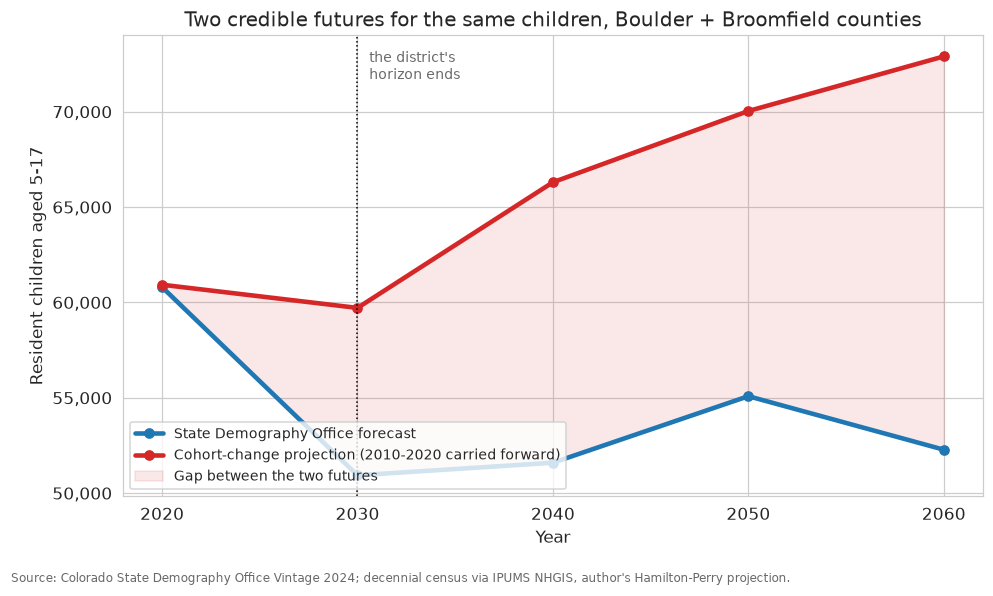

In [30]:
f, ax = plt.subplots(figsize=(9, 5.2))
years_l = [2020] + PROJ_YEARS
ax.plot(years_l, fork_df['sdo_5_17'], color=SDO_COLOR, lw=3, marker='o',
        label='State Demography Office forecast')
ax.plot(years_l, fork_df['hp_5_17'], color=HP_COLOR, lw=3, marker='o',
        label='Cohort-change projection (2010-2020 carried forward)')
ax.fill_between(years_l, fork_df['sdo_5_17'], fork_df['hp_5_17'],
                color=mcolors.to_rgba(HP_COLOR, 0.10), label='Gap between the two futures')
ax.axvline(2030, color='k', lw=1, ls=':')
ax.text(2030.6, ax.get_ylim()[1] * 0.99, "the district's\nhorizon ends", fontsize=9, color='dimgray', va='top')
ax.set_ylabel('Resident children aged 5-17')
ax.set_xlabel('Year')
ax.set_xticks(years_l)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.set_title('Two credible futures for the same children, Boulder + Broomfield counties')
ax.legend(loc='lower left', fontsize=9)
f.text(0, -0.03, 'Source: Colorado State Demography Office Vintage 2024; decennial census via IPUMS NHGIS, '
                 'author\'s Hamilton-Perry projection.', fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig6-two-futures.png', bbox_inches='tight')

## Where both futures come from: one mechanism, not two

The district's list separates falling births from high cost of living. The state's own components
of change put them in the same place.

Births in the two counties have fallen since 2000. Deaths overtake births within the forecast
period. And net migration stays positive throughout — the counties keep adding people, and keep
adding adults in particular. A county that grows by importing adults while its child cohorts
shrink is receiving more than a national fertility trend; it is a place where the people arriving
are not the people who have children there, and where the people who would have are elsewhere.

That is the same fact the housing series below describes from the price side.

In [31]:
c0 = components_df['countyfips'].isin(BVSD_COUNTIES)
change_df = components_df.loc[c0].groupby('year')[['births', 'deaths', 'netmig']].sum()
change_df['natural_increase'] = change_df['births'] - change_df['deaths']

births_2000, births_2024 = change_df.loc[2000, 'births'], change_df.loc[2024, 'births']
births_change_pct = (births_2024 / births_2000 - 1) * 100
natural_decrease_year = int(change_df.loc[2020:].query('natural_increase < 0').index.min())
netmig_recent = change_df.loc[2015:2024, 'netmig'].mean()
netmig_forecast = change_df.loc[2025:2050, 'netmig'].mean()

print(f'births: {births_2000:,.0f} (2000) -> {births_2024:,.0f} (2024) = {births_change_pct:+.0f}%')
print(f'deaths overtake births in {natural_decrease_year}')
print(f'net migration: {netmig_recent:+,.0f}/yr observed 2015-2024 · {netmig_forecast:+,.0f}/yr forecast 2025-2050')
print('  -> the counties keep importing adults through the whole period the child cohorts shrink')
change_df.loc[[2000, 2010, 2020, 2024, 2030, 2040, 2050, 2060]].round(0)

births: 3,719 (2000) -> 2,980 (2024) = -20%
deaths overtake births in 2031
net migration: +2,368/yr observed 2015-2024 · +2,723/yr forecast 2025-2050
  -> the counties keep importing adults through the whole period the child cohorts shrink


,births,deaths,netmig,natural_increase
year,,,,
2000,3719,1388,28540,2331
2010,3831,1815,677,2016
2020,3149,2472,3280,677
2024,2980,2691,2690,289
2030,3129,3088,2871,41
2040,3546,3932,3164,-386
2050,3313,4523,2545,-1210
2060,3102,4850,2545,-1748


### Households with children

The share of households that contain a child is the cleanest single measure of whether a place is
one families live in. This series is the household projection, which the State Demography Office
publishes only through 2050. It is not extended past that year here, and it stops earlier than
every other series in this notebook for that reason.

In [32]:
c0 = households_df['area_code'].isin(BVSD_COUNTIES)
c1 = households_df['age_group_id'] == 0          # all householder ages
c2 = households_df['household_type_id'].isin([2, 4])   # one adult with kids, two-plus adults with kids
c3 = households_df['household_type_id'] == 0     # all households

households_kids_df = pd.DataFrame({
    'with_kids': households_df.loc[c0 & c1 & c2].groupby('year')['total_households'].sum(),
    'all_households': households_df.loc[c0 & c1 & c3].groupby('year')['total_households'].sum()})
households_kids_df['share_with_kids_pct'] = (households_kids_df['with_kids']
                                             / households_kids_df['all_households'] * 100)

hh_share_2010 = households_kids_df.loc[2010, 'share_with_kids_pct']
hh_share_2025 = households_kids_df.loc[2025, 'share_with_kids_pct']
hh_share_2050 = households_kids_df.loc[2050, 'share_with_kids_pct']
print(f'share of households with a child: {hh_share_2010:.1f}% (2010) -> {hh_share_2025:.1f}% (2025) '
      f'-> {hh_share_2050:.1f}% (2050)')
print(f'series ends at {HOUSEHOLD_LAST_YEAR}: the SDO household projection does not run to 2060, '
      'and is not extended here')
households_kids_df.loc[[2010, 2020, 2025, 2030, 2040, 2050]].round(1)

share of households with a child: 32.2% (2010) -> 27.6% (2025) -> 24.9% (2050)
series ends at 2050: the SDO household projection does not run to 2060, and is not extended here


,with_kids,all_households,share_with_kids_pct
year,,,
2010,45377,141066,32.2
2020,47510,163339,29.1
2025,46732,169028,27.6
2030,47451,176081,26.9
2040,49361,189768,26.0
2050,50046,200628,24.9


### Housing cost, 1975 to today

Everything in this section is **county** data, for two reasons. The Boulder MSA is Boulder County
and has never contained any other county, so nothing is gained by mixing the two labels. And the
peer basket has no metropolitan series that lines up with it, while every peer county does have
both a price and an income series.

Prices are the [FHFA All-Transactions House Price Index](https://www.fhfa.gov/data/hpi) at county
grain, and incomes are the Census Bureau's
[Small Area Income and Poverty Estimates](https://www.census.gov/programs-surveys/saipe.html) of
median household income, both read from [FRED](https://fred.stlouisfed.org/). The peer counties
come from `data/processed/places.csv`, this piece's own copy of the
[similar-cities basket](https://github.com/brianckeegan/charting-boulder/blob/main/2025-06-population/similar-boulder.json).

Two caveats travel with the series. The all-transactions index is built from purchase prices and
refinance appraisals together, so it is smoother and slower than a purchase-only index; it is used
because it is the FHFA county index that reaches back to 1975. SAIPE incomes are model-based
estimates rather than survey tabulations, built to be comparable across counties and years, with
wider margins in small counties; the ratio inherits both properties.

Two gaps to know about. The income series publishes no value for 1990, 1991, 1992, 1994 or 1996,
in every county alike. That leaves 1989, 1993 and 1995 as isolated years that no line can join, so
the price-to-income figure below draws the continuous window from 1997 on; all three earlier years stay in the
frame and in the exported table. And New Haven County's income stops in 2021, when Connecticut
replaced counties with planning regions for federal statistics.

Both series arrive annual, one row per county-year.

In [33]:
# Wide frames, year down the rows and county across the columns, so the two divide cell by cell.
# Some counties have no price index in the earliest years and the income series skips five, so the
# pivot leaves those cells empty rather than filled.
hpi_long_df = pd.read_csv(PROC / 'county-hpi.csv', dtype={'county_fips': str})
income_long_df = pd.read_csv(PROC / 'county-income.csv', dtype={'county_fips': str})
hpi_df = hpi_long_df.pivot(index='year', columns='city', values='value')
income_df = income_long_df.pivot(index='year', columns='city', values='value')

# Three groups: Boulder County, the 25 peer counties, and the Front Range corridor counties.
# The Front Range rule is the one figure 3 defines, so one definition runs through the piece.
HOUSING_BOULDER = 'Boulder'
peer_counties_l = sorted(places_df.loc[places_df['tier'] == 2, 'name'])

# The Front Range group is the one figure 3 already defined: corridor counties at or above 50,000
# residents, Boulder excluded. Membership is carried by county FIPS, not by the label the fetch
# happened to use, because Larimer County is a Front Range county AND the county Fort Collins
# names, so it belongs to both groups here.
label_of_fips_d = dict(zip(hpi_long_df['county_fips'], hpi_long_df['city']))
fips_of_county_d = {name: f'08{code:03d}' for name, code
                    in sya_df[['county', 'countyfips']].drop_duplicates().itertuples(index=False)}
front_range_housing_l = sorted(label_of_fips_d[fips_of_county_d[name]]
                               for name in comparison_counties_l)

# Integrity checks
assert set(hpi_df.columns) == set(income_df.columns), 'the two series cover different counties'
assert HOUSING_BOULDER in hpi_df.columns and len(peer_counties_l) == 25
assert HOUSING_BOULDER not in peer_counties_l and HOUSING_BOULDER not in front_range_housing_l, \
    'Boulder is inside a group it is compared against'
assert len(front_range_housing_l) == 10, f'expected 10 Front Range counties; got {len(front_range_housing_l)}'
assert set(front_range_housing_l) <= set(hpi_df.columns), 'a Front Range county has no price series'
for label, frame in [('house price index', hpi_df), ('median income', income_df)]:
    values = frame.to_numpy(dtype=float)
    assert (values[~np.isnan(values)] > 0).all(), f'non-positive {label}'
assert income_df.index.min() == 1989 and hpi_df.index.min() <= 1975
assert (hpi_df.loc[2000] - 100).abs().max() < 0.05, 'the index is not based at 2000'
income_gap_years_l = sorted(set(range(income_df.index.min(), income_df.index.max() + 1))
                            - set(income_df.dropna(how='all').index))
assert income_gap_years_l == [1990, 1991, 1992, 1994, 1996], f'unexpected income gaps: {income_gap_years_l}'

overlap_l = sorted(set(front_range_housing_l) & set(peer_counties_l))
print(f'{hpi_df.shape[1]} counties · Boulder + {len(peer_counties_l)} peers + '
      f'{len(front_range_housing_l)} Front Range')
print(f'  Front Range: {", ".join(front_range_housing_l)}')
print(f'  in both groups: {", ".join(overlap_l) or "none"} '
      f'(a county can be a peer and a Front Range county at once)')
print(f'  house price index {hpi_df.index.min()}-{hpi_df.index.max()} · '
      f'median household income {income_df.index.min()}-{income_df.index.max()}')
print(f'income publishes no value for {income_gap_years_l} in every county')
print('income series ending before 2024:',
      {city: int(income_df[city].dropna().index.max()) for city in income_df
       if income_df[city].dropna().index.max() < 2024})

41 counties · Boulder + 25 peers + 10 Front Range
  Front Range: Adams, Arapahoe, Broomfield, Denver, Douglas, El Paso, Fort Collins, Jefferson, Pueblo, Weld
  in both groups: Fort Collins (a county can be a peer and a Front Range county at once)
  house price index 1975-2025 · median household income 1989-2024
income publishes no value for [1990, 1991, 1992, 1994, 1996] in every county
income series ending before 2024: {'New Haven': 2021}


### Price per dollar of income

Each county's price index is divided by its income index, both based at 2000. Each comparison
group is then reduced to a median and its middle half, computed over whichever members report in
a given year.

In [34]:
INDEX_BASE = 2000

# Index prices and incomes to the same base year, then divide: how much house price each dollar
# of median income buys, relative to what it bought in 2000.
hpi_indexed_df = hpi_df / hpi_df.loc[INDEX_BASE] * 100
income_indexed_df = income_df / income_df.loc[INDEX_BASE] * 100
# The division aligns on the union of years; rows with no income anywhere are dropped, so the
# frame starts at the first income year and ends at the last one the source publishes
price_income_df = (hpi_indexed_df / income_indexed_df * 100).dropna(how='all')

assert abs(price_income_df.loc[INDEX_BASE] - 100).max() < 1e-9, 'the base year must equal 100'

# 1989, 1993 and 1995 stand alone between the gap years; the drawn window starts where the
# annual series becomes continuous, but the frame keeps every published year.
FIRST_CONTINUOUS_YEAR = 1997
latest_ratio_year = int(price_income_df[HOUSING_BOULDER].dropna().index.max())

def group_band(frame, members_l):
    # Median and the middle half, over whichever members report in a given year. Membership can
    # change: Broomfield's income starts in 2001, New Haven's ends in 2021.
    part_df = frame[members_l]
    return pd.DataFrame({'median': part_df.median(axis=1),
                         'lo': part_df.quantile(0.25, axis=1),
                         'hi': part_df.quantile(0.75, axis=1),
                         'n': part_df.notna().sum(axis=1)})

HOUSING_GROUPS = [('peer counties', peer_counties_l, PEER_C),
                  ('Front Range counties', front_range_housing_l, NATION_C)]
ratio_band_d = {name: group_band(price_income_df, members_l) for name, members_l, _ in HOUSING_GROUPS}
price_band_d = {name: group_band(hpi_df, members_l) for name, members_l, _ in HOUSING_GROUPS}

boulder_ratio_latest = price_income_df.loc[latest_ratio_year, HOUSING_BOULDER]
peer_ratio_latest_s = price_income_df.loc[latest_ratio_year, peer_counties_l].dropna()
fr_ratio_latest_s = price_income_df.loc[latest_ratio_year, front_range_housing_l].dropna()
peers_above_boulder = int((peer_ratio_latest_s > boulder_ratio_latest).sum())
boulder_pctile = float((peer_ratio_latest_s < boulder_ratio_latest).mean() * 100)
hpi_growth_since_1975 = hpi_df.loc[hpi_df.index.max(), HOUSING_BOULDER] / hpi_df.loc[1975, HOUSING_BOULDER]

assert not price_income_df.loc[FIRST_CONTINUOUS_YEAR:latest_ratio_year, HOUSING_BOULDER].isna().any(), \
    'the drawn Boulder line has a hole in it'

In [35]:
# A county with no income in the base year has no ratio at all, and would otherwise vanish from
# the price-to-income figure without anyone noticing. Broomfield County was created in 2001.
no_ratio_l = sorted(price_income_df.columns[price_income_df.notna().sum() == 0])
assert set(no_ratio_l) <= {'Broomfield'}, f'unexpected county with no ratio: {no_ratio_l}'
print(f'no {INDEX_BASE}-based ratio, so absent from the price-to-income figure throughout: '
      f'{", ".join(no_ratio_l) or "none"} (no income in {INDEX_BASE})')

print(f'House price per dollar of median income, index {INDEX_BASE} = 100, in {latest_ratio_year}:')
print(f'  Boulder County        {boulder_ratio_latest:5.0f}')
print(f'  peer county median    {peer_ratio_latest_s.median():5.0f}   ({len(peer_ratio_latest_s)} counties reporting)')
print(f'  Front Range median    {fr_ratio_latest_s.median():5.0f}   ({len(fr_ratio_latest_s)} counties reporting)')
print(f'  Boulder is higher than {boulder_pctile:.0f}% of the peer counties; '
      f'{peers_above_boulder} sit above it')
print(f'  Boulder is higher than {int((fr_ratio_latest_s < boulder_ratio_latest).sum())} of '
      f'{len(fr_ratio_latest_s)} Front Range counties')

print(f'\nHouse price index (2000 = 100) in {int(hpi_df.index.max())}:')
print(f'  Boulder County        {hpi_df.loc[hpi_df.index.max(), HOUSING_BOULDER]:5.0f}')
for name, members_l, _ in HOUSING_GROUPS:
    print(f'  {name:<21} {hpi_df.loc[hpi_df.index.max(), members_l].median():5.0f}')
print(f'\nBoulder County house prices are {hpi_growth_since_1975:.1f}x their 1975 index level')

housing_summary_df = pd.DataFrame(
    {'Boulder County': price_income_df[HOUSING_BOULDER],
     'peer county median': ratio_band_d['peer counties']['median'],
     'Front Range median': ratio_band_d['Front Range counties']['median']}).loc[FIRST_CONTINUOUS_YEAR:]
housing_summary_df.round(1)

no 2000-based ratio, so absent from the price-to-income figure throughout: Broomfield (no income in 2000)
House price per dollar of median income, index 2000 = 100, in 2024:
  Boulder County          164
  peer county median      140   (24 counties reporting)
  Front Range median      151   (9 counties reporting)
  Boulder is higher than 88% of the peer counties; 3 sit above it
  Boulder is higher than 8 of 9 Front Range counties

House price index (2000 = 100) in 2025:
  Boulder County          289
  peer counties           287
  Front Range counties    282

Boulder County house prices are 17.7x their 1975 index level


,Boulder County,peer county median,Front Range median
year,,,
1997,87.3,93.9,91.7
1998,84.5,91.8,88.6
1999,89.1,97.6,91.6
2000,100.0,100.0,100.0
2001,113.3,107.4,108.6
2002,120.5,111.0,113.9
2003,117.8,113.5,113.8
2004,118.4,117.7,116.1
2005,123.6,124.9,121.3


Both housing figures set Boulder County against two comparison groups: the 25 peer counties, and the Front
Range corridor counties that figure 3 uses. Each group is drawn as one median line over the middle
half of its members, so the spread stays visible without forty overlapping county lines.

The two figures do not say the same thing, and the difference is the point. On prices alone Boulder
County is unremarkable: it ends 2025 at 289 against a peer median of 287 and a Front Range median
of 282, three lines that are hard to tell apart. Set against what people earn, it separates. In
2024 Boulder County stands at 164 against a peer median of 140 and a Front Range median of 151,
higher than 88% of its peers and than 8 of the 9 Front Range counties that have a ratio. Boulder's
prices did not rise faster than everyone else's. Its incomes failed to keep up with them.

Read every line as counties, not cities. For several peers the county is far larger than the city
the basket names — Pasadena sits inside Los Angeles County, Mountain View inside Santa Clara,
Cambridge inside Middlesex, Evanston inside Cook — so those lines describe a housing market much
bigger than the city. Boulder is the unusual case where city, county and metropolitan area sit
close together. Larimer County appears in both groups, as a peer county because Fort Collins names
it and as a Front Range county because it is one.


FIGURE 7 ROWS — house price index, paste into Datawrapper
year,Boulder County,peer county median,Front Range median
1975,16.3,23.8,20.9
1976,18.0,26.1,23.0
1977,21.4,31.0,26.2
1978,25.4,35.4,31.6
1979,29.5,39.6,36.7
1980,31.9,41.9,41.0
1981,33.9,45.2,42.6
1982,38.9,44.0,46.2
1983,38.4,47.3,49.3
1984,39.6,49.0,49.0
1985,40.4,52.2,49.6
1986,41.6,55.4,51.1
1987,42.0,59.1,50.8
1988,42.3,63.2,48.7
1989,43.3,66.8,49.6
1990,44.7,68.0,50.1
1991,46.8,70.4,51.5
1992,50.9,72.1,54.5
1993,57.2,74.6,59.6
1994,64.0,75.8,65.7
1995,69.1,81.2,71.4
1996,71.4,83.8,73.9
1997,74.9,87.2,77.2
1998,78.6,89.1,81.0
1999,85.3,93.2,87.1
2000,100.0,100.0,100.0
2001,110.4,106.2,108.7
2002,114.7,110.5,113.4
2003,114.8,113.6,114.5
2004,117.0,119.6,117.8
2005,123.0,133.0,122.6
2006,125.8,139.4,123.5
2007,127.2,143.8,123.3
2008,128.9,143.1,119.8
2009,127.6,135.9,118.4
2010,125.2,134.8,115.5
2011,122.7,131.9,112.1
2012,124.0,131.7,112.9
2013,129.6,134.1,121.0
2014,141.7,139.9,131.2
2015,155.5,147.4,144.7
2016,175.2,152.

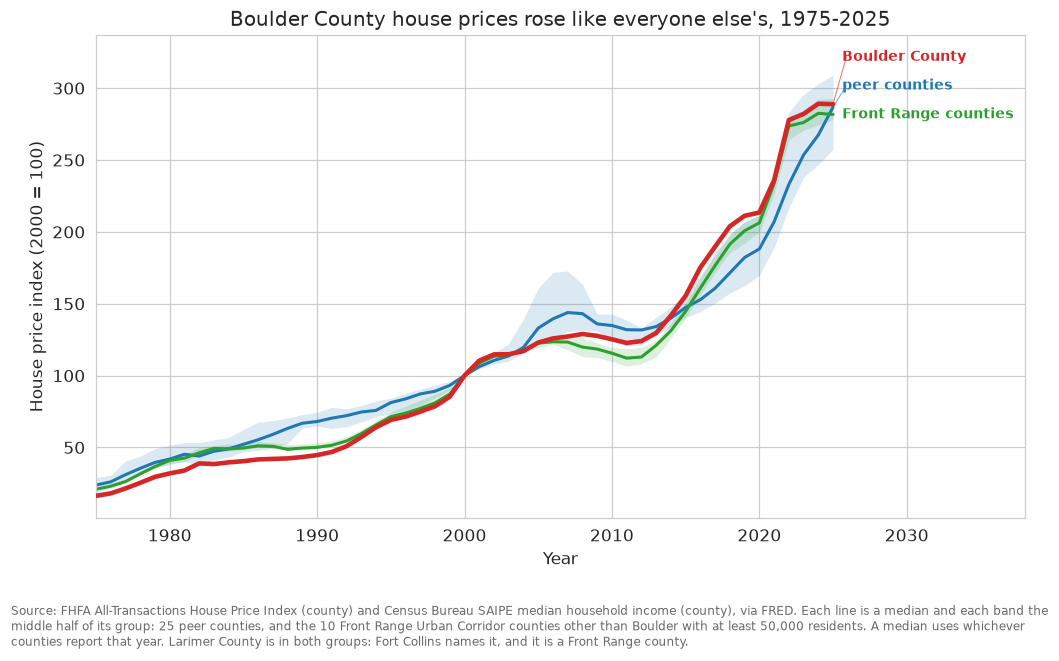

In [36]:
def draw_groups(ax, boulder_s, band_d, first_year):
    # Each group is one median line over its own 25th-to-75th band, so the spread is visible
    # without forty overlapping county lines
    for name, _, color in HOUSING_GROUPS:
        band_df = band_d[name].loc[first_year:]
        ax.fill_between(band_df.index, band_df['lo'], band_df['hi'], color=color, alpha=0.16, lw=0)
        ax.plot(band_df.index, band_df['median'], color=color, lw=2)
    drawn_s = boulder_s.loc[first_year:]
    ax.plot(drawn_s.index, drawn_s, color=HP_COLOR, lw=3, zorder=5)

def label_ends(ax, entries_l, x_value, min_gap):
    # Three lines can finish within a couple of points of each other, so the labels are pushed
    # apart to a minimum gap while keeping their order
    placed_l, previous = [], None
    for label, value, color in sorted(entries_l, key=lambda item: item[1]):
        target = value if previous is None else max(value, previous + min_gap)
        placed_l.append((label, value, target, color))
        previous = target
    for label, value, target, color in placed_l:
        ax.annotate(label, (x_value, target), color=color, fontweight='bold', fontsize=9,
                    va='center', xytext=(6, 0), textcoords='offset points', annotation_clip=False)
        if abs(target - value) > min_gap / 4:      # a short leader where the label had to move
            ax.plot([x_value, x_value + 0.9], [value, target], color=color, lw=0.7, alpha=0.6,
                    clip_on=False)

HOUSING_SOURCE = ('Source: FHFA All-Transactions House Price Index (county) and Census Bureau SAIPE '
                  'median household income (county), via FRED.')
GROUP_NOTE = (f'Each line is a median and each band the middle half of its group: '
              f'{len(peer_counties_l)} peer counties, and the {len(front_range_housing_l)} Front '
              f'Range Urban Corridor counties other than Boulder with at least '
              f'{FRONT_RANGE_MIN_POP:,} residents. A median uses whichever counties report that '
              f'year. Larimer County is in both groups: Fort Collins names it, and it is a Front '
              f'Range county.')

first_price_year, last_price_year = int(hpi_df.index.min()), int(hpi_df.index.max())
f, ax = plt.subplots(figsize=(9.5, 5.4))
draw_groups(ax, hpi_df[HOUSING_BOULDER], price_band_d, first_price_year)
ax.set_ylabel(f'House price index ({INDEX_BASE} = 100)')
ax.set_xlabel('Year')
label_ends(ax, [('Boulder County', hpi_df.loc[last_price_year, HOUSING_BOULDER], HP_COLOR)]
           + [(name, price_band_d[name].loc[last_price_year, 'median'], color)
              for name, _, color in HOUSING_GROUPS], last_price_year, 20)
ax.set_xlim(first_price_year, last_price_year + 13)
ax.set_title(f"Boulder County house prices rose like everyone else's, "
             f'{first_price_year}-{last_price_year}')
f.text(0, -0.10, f'{HOUSING_SOURCE} {GROUP_NOTE}', fontsize=8, color='dimgray', wrap=True)
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig7-house-prices.png', bbox_inches='tight')

price_summary_df = pd.DataFrame(
    {'Boulder County': hpi_df[HOUSING_BOULDER],
     'peer county median': price_band_d['peer counties']['median'],
     'Front Range median': price_band_d['Front Range counties']['median']})
price_summary_df.round(1).to_csv(OUT / 'bvsd-fig7-house-prices.csv')
print(f"\n{'=' * 78}\nFIGURE 7 ROWS — house price index, paste into Datawrapper\n{'=' * 78}")
print(price_summary_df.round(1).to_csv().strip())

Prices alone say Boulder County is ordinary. Dividing by what people earn is what separates it.

The next figure divides each county's price index by its income index, both based at 2000, so a
value of 150 means house prices have grown half again as fast as median household income since
2000. It is a relative measure, not a statement that houses cost some multiple of income.


FIGURE 8 ROWS — price per dollar of income, paste into Datawrapper
year,Boulder County,peer 25th,peer median,peer 75th,Front Range 25th,Front Range median,Front Range 75th,peer counties reporting,Front Range counties reporting
1997,87.3,86.8,93.9,96.3,84.6,91.7,100.6,25,9
1998,84.5,88.1,91.8,96.2,85.3,88.6,99.2,25,9
1999,89.1,94.8,97.6,100.4,90.2,91.6,98.1,25,9
2000,100.0,100.0,100.0,100.0,100.0,100.0,100.0,25,9
2001,113.3,105.9,107.4,110.8,108.2,108.6,109.3,25,9
2002,120.5,109.1,111.0,119.1,112.8,113.9,114.5,25,9
2003,117.8,109.1,113.5,124.4,111.6,113.8,114.5,25,9
2004,118.4,112.7,117.7,133.6,112.6,116.1,116.5,25,9
2005,123.6,118.7,124.9,148.4,113.1,121.3,123.5,25,9
2006,118.3,116.3,124.5,153.0,111.6,120.6,123.5,25,9
2007,115.9,114.3,123.2,151.3,102.7,114.9,119.9,25,9
2008,113.2,110.0,116.8,131.5,94.9,108.8,109.8,25,9
2009,117.3,112.1,116.9,123.6,101.1,109.4,112.0,25,9
2010,117.9,110.1,113.9,122.2,98.0,108.7,111.1,25,9
2011,105.6,104.3,108.5,115.3,90.8,106.9,107.8,25,9
2012,108.6,102

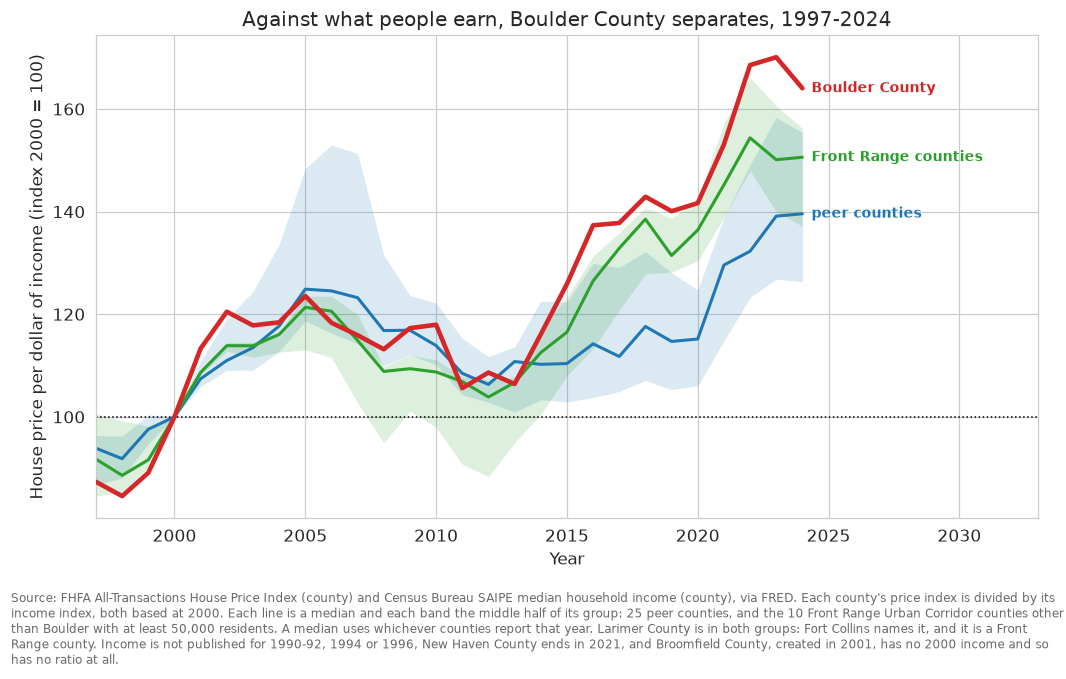

In [37]:
f, ax = plt.subplots(figsize=(9.5, 5.4))
draw_groups(ax, price_income_df[HOUSING_BOULDER], ratio_band_d, FIRST_CONTINUOUS_YEAR)
ax.axhline(100, color='k', lw=1, ls=':')
ax.set_ylabel(f'House price per dollar of income (index {INDEX_BASE} = 100)')
ax.set_xlabel('Year')
ax.set_xlim(FIRST_CONTINUOUS_YEAR, latest_ratio_year + 9)
label_ends(ax, [('Boulder County', boulder_ratio_latest, HP_COLOR)]
           + [(name, ratio_band_d[name].loc[latest_ratio_year, 'median'], color)
              for name, _, color in HOUSING_GROUPS], latest_ratio_year, 8)
ax.set_title(f'Against what people earn, Boulder County separates, '
             f'{FIRST_CONTINUOUS_YEAR}-{latest_ratio_year}')
f.text(0, -0.13, f"{HOUSING_SOURCE} Each county's price index is divided by its income index, both "
                 f'based at {INDEX_BASE}. {GROUP_NOTE} Income is not published for 1990-92, 1994 or '
                 f'1996, New Haven County ends in 2021, and Broomfield County, created in 2001, has '
                 f'no {INDEX_BASE} income and so has no ratio at all.',
       fontsize=8, color='dimgray', wrap=True)
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig8-price-to-income.png', bbox_inches='tight')

# The drawn rows in full: Boulder's line, then each group's band and median. The two count
# columns are the last two because group membership changes year to year — Broomfield has no
# ratio at all, and New Haven leaves after 2021.
ratio_export_df = pd.DataFrame({
    'Boulder County': price_income_df[HOUSING_BOULDER],
    'peer 25th': ratio_band_d['peer counties']['lo'],
    'peer median': ratio_band_d['peer counties']['median'],
    'peer 75th': ratio_band_d['peer counties']['hi'],
    'Front Range 25th': ratio_band_d['Front Range counties']['lo'],
    'Front Range median': ratio_band_d['Front Range counties']['median'],
    'Front Range 75th': ratio_band_d['Front Range counties']['hi'],
    'peer counties reporting': ratio_band_d['peer counties']['n'],
    'Front Range counties reporting': ratio_band_d['Front Range counties']['n'],
}).loc[FIRST_CONTINUOUS_YEAR:latest_ratio_year].round(1)
ratio_export_df.index.name = 'year'

# Each band must bracket its own median, or the columns are mislabelled
for group in ['peer', 'Front Range']:
    assert (ratio_export_df[f'{group} 25th'] <= ratio_export_df[f'{group} median'] + 1e-9).all()
    assert (ratio_export_df[f'{group} 75th'] >= ratio_export_df[f'{group} median'] - 1e-9).all()

ratio_export_df.to_csv(OUT / 'bvsd-fig8-price-to-income.csv')
print(f"\n{'=' * 78}\nFIGURE 8 ROWS — price per dollar of income, paste into Datawrapper\n{'=' * 78}")
print(ratio_export_df.to_csv().strip())

### What got built, and where

The two housing figures above are about price. This one is about supply: how much housing each place
authorized over the sixteen years to 2025, and of what kind.

The permits come from the
[Census Building Permits Survey](https://www.census.gov/construction/bps/) place files, and the
county totals from [FRED](https://fred.stlouisfed.org/).

Two things make this the sharpest test in the piece of the column's argument. It is measured at
**city** grain, so it is about the City of Boulder rather than its county. And the Census splits
permits by structure size, so a detached house and a studio in a two-hundred-unit building are not
counted as the same product. The schools proposed for closure are in the city, and the children
who would fill them live in family-sized housing.

Rates are units authorized per 1,000 residents of the **2010** census, the start of the window: a
cumulative flow is read against the community that existed when the window opened, so a place that
doubled does not get to divide by its larger self. The 2020-based rate is printed beside it.

A place that reports fewer than twelve months has the rest imputed by the Census Bureau, and the
annual totals used here include those months as published. The cell names every charted place
with an imputed year, so a reader can see which totals rest partly on imputation.

Two places behave differently in the source, and neither is dropped quietly. Bloomington, Indiana
files no separate place record, so it appears only in the county table. New Haven files a full
sixteen years as a city even though FRED's New Haven **County** series was discontinued in 2022.

In [38]:
PERMIT_START, PERMIT_END = 2010, 2025
EARLY_YEARS, LATE_YEARS = (2010, 2011, 2012), (2023, 2024, 2025)
FAMILY_SIZE = '1-unit'          # the only size class that is unambiguously a detached house

place_permits_df = pd.read_csv(PROC / 'place-permits.csv', dtype={'place_fips': str})
county_permits_df = pd.read_csv(PROC / 'county-permits.csv', dtype={'county_fips': str})
place_housing_df = (pd.read_csv(PROC / 'place-housing-units.csv', dtype={'place_fips': str})
                    .pivot(index='place_fips', columns='year', values='housing_units'))

# Denominators are census counts already in hand, so no third population source enters here
place_pop_df = (place_age_groups_df.groupby(['place_fips', 'year'])['pop'].sum().unstack('year'))
county_pop_df = (county_age_groups_df.groupby(['county_fips', 'year'])['pop'].sum().unstack('year'))

def permit_rates(units_s, population, label):
    # units_s is indexed by year; population is a single count, the denominator for every measure
    cumulative = units_s.reindex(range(PERMIT_START, PERMIT_END + 1)).fillna(0).sum()
    early = units_s.reindex(EARLY_YEARS).mean()
    late = units_s.reindex(LATE_YEARS).mean()
    return {'name': label, 'cum_units': cumulative,
            'cum_per_1k': cumulative / population * 1000,
            'early_per_1k': early / population * 1000,
            'late_per_1k': late / population * 1000,
            'delta_per_1k': (late - early) / population * 1000}

city_l = []
for place_fips, frame in place_permits_df.groupby('place_fips'):
    name = place_name_s[place_fips]
    by_year_s = frame.groupby('year')['units'].sum()
    row = permit_rates(by_year_s, place_pop_df.loc[place_fips, 2010], name)
    family_s = frame.loc[frame['size_class'] == FAMILY_SIZE].groupby('year')['units'].sum()
    row['family_units'] = family_s.reindex(range(PERMIT_START, PERMIT_END + 1)).fillna(0).sum()
    row['family_share'] = row['family_units'] / row['cum_units'] * 100
    row['cum_per_1k_2020_base'] = row['cum_units'] / place_pop_df.loc[place_fips, 2020] * 1000
    # Second denominator: the stock being added to, rather than the people living in it
    stock_2010 = place_housing_df.loc[place_fips, 2010]
    row['housing_units_2010'] = stock_2010
    row['housing_units_2020'] = place_housing_df.loc[place_fips, 2020]
    row['cum_per_1k_stock'] = row['cum_units'] / stock_2010 * 1000
    # A permit is an authorization, not a building. Compare the counted change in stock over
    # 2010-2020 against the units permitted in the same years; the gap is lapses and demolitions.
    row['permits_2010_2020'] = by_year_s.reindex(range(2010, 2021)).fillna(0).sum()
    row['stock_change_2010_2020'] = row['housing_units_2020'] - stock_2010
    row['realized_pct'] = row['stock_change_2010_2020'] / row['permits_2010_2020'] * 100
    row['tier'] = int(places_df.loc[places_df['place_fips'] == place_fips, 'tier'].iloc[0])
    city_l.append(row)
city_permits_df = pd.DataFrame(city_l).set_index('name').sort_values('cum_per_1k')

# Integrity checks
assert city_permits_df['cum_units'].gt(0).all(), 'a city authorized nothing in sixteen years'
assert city_permits_df['family_share'].between(0, 100).all(), 'family share outside 0-100'
assert city_permits_df['housing_units_2010'].gt(0).all(), 'a city counted no housing in 2010'
assert 'Boulder' in city_permits_df.index, 'the subject city is missing'

boulder_permits_s = city_permits_df.loc['Boulder']
peer_cities_df = city_permits_df[(city_permits_df['tier'] == 2)]
ring_cities_df = city_permits_df[(city_permits_df['tier'] == 1) & (city_permits_df.index != 'Boulder')]

# Place-years the Census filled in, named rather than counted
c0 = place_permits_df.drop_duplicates(['place_fips', 'year'])['months_reported'] < 12
imputed_years_s = (place_permits_df.drop_duplicates(['place_fips', 'year']).loc[c0]
                   .groupby('place_fips')['year']
                   .apply(lambda years_s: ', '.join(str(year) for year in years_s)))
imputed_years_s.index = imputed_years_s.index.map(place_name_s)
print(f'{len(city_permits_df)} cities file a place record; {len(imputed_years_s)} have a year with '
      'fewer than 12 months reported, the rest imputed by the Census:')
print(imputed_years_s.sort_index().to_string())

30 cities file a place record; 21 have a year with fewer than 12 months reported, the rest imputed by the Census:
place_fips
Ann Arbor                                         2010, 2024, 2025
Baton Rouge                           2011, 2015, 2022, 2023, 2024
Berkeley                              2016, 2017, 2020, 2024, 2025
Boulder                                     2018, 2020, 2022, 2023
Cambridge        2013, 2015, 2016, 2017, 2018, 2019, 2020, 2021...
Chapel Hill                                                   2023
Durham                    2011, 2016, 2017, 2018, 2023, 2024, 2025
Erie                                              2020, 2023, 2024
Evanston                                          2010, 2011, 2013
Gainesville      2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018...
Lafayette                       2014, 2015, 2016, 2017, 2018, 2020
Longmont                                                      2025
Louisville                                                    2013
Madi

In [39]:
print(f'Units authorized {PERMIT_START}-{PERMIT_END} per 1,000 residents of the 2010 census:')
print(f"  City of Boulder    {boulder_permits_s.cum_per_1k:6.0f}   "
      f"{FAMILY_SIZE} share {boulder_permits_s.family_share:.0f}%")
print(f"  peer city median   {peer_cities_df.cum_per_1k.median():6.0f}   "
      f"{FAMILY_SIZE} share {peer_cities_df.family_share.median():.0f}%   ({len(peer_cities_df)} cities)")
print(f"  ring town median   {ring_cities_df.cum_per_1k.median():6.0f}   "
      f"{FAMILY_SIZE} share {ring_cities_df.family_share.median():.0f}%   ({len(ring_cities_df)} towns)")
print(f"\nBoulder ranks {int((peer_cities_df.cum_per_1k > boulder_permits_s.cum_per_1k).sum()) + 1} of "
      f'{len(peer_cities_df) + 1} on total, and '
      f"{int((peer_cities_df.family_share > boulder_permits_s.family_share).sum()) + 1} of "
      f'{len(peer_cities_df) + 1} on the {FAMILY_SIZE} share.')
print(f'\nChange in the annual rate, {EARLY_YEARS[0]}-{EARLY_YEARS[-1]} mean to '
      f'{LATE_YEARS[0]}-{LATE_YEARS[-1]} mean, per 1,000:')
print(f'  City of Boulder  {boulder_permits_s.delta_per_1k:+6.1f}   '
      f'peer median {peer_cities_df.delta_per_1k.median():+.1f}   '
      f'ring towns {ring_cities_df.delta_per_1k.median():+.1f}')

print('\nThe same permits against the stock they were added to, per 1,000 housing units of 2010:')
for label, value in [('City of Boulder', boulder_permits_s.cum_per_1k_stock),
                     ('peer city median', peer_cities_df.cum_per_1k_stock.median()),
                     ('ring town median', ring_cities_df.cum_per_1k_stock.median())]:
    print(f'  {label:<18} {value:6.0f}   ({value / 10:.1f}% of the 2010 stock)')
# Counted stock change against units permitted, 2010-2020. Read this as a consistency check, not
# as a completion rate: it runs from 28% to 258% across the basket, because annexation, conversion
# and demolition all move the counted stock without a permit in this series, and the two censuses
# count units on their own definition.
realized_all_s = city_permits_df['realized_pct']
print('\nCounted stock change over units permitted, 2010-2020 (a consistency check, not a '
      'completion rate):')
print(f'  City of Boulder  {boulder_permits_s.realized_pct:5.0f}%   '
      f'peer median {peer_cities_df.realized_pct.median():.0f}%   '
      f'ring towns {ring_cities_df.realized_pct.median():.0f}%')
print(f'  across all {len(realized_all_s)} places it runs {realized_all_s.min():.0f}% to '
      f'{realized_all_s.max():.0f}%, so no single value carries much weight')
city_permits_df.round(1)

Units authorized 2010-2025 per 1,000 residents of the 2010 census:
  City of Boulder        62   1-unit share 17%
  peer city median       72   1-unit share 29%   (24 cities)
  ring town median      127   1-unit share 55%   (5 towns)

Boulder ranks 15 of 25 on total, and 16 of 25 on the 1-unit share.

Change in the annual rate, 2010-2012 mean to 2023-2025 mean, per 1,000:
  City of Boulder    +0.0   peer median +2.2   ring towns +9.6

The same permits against the stock they were added to, per 1,000 housing units of 2010:
  City of Boulder       138   (13.8% of the 2010 stock)
  peer city median      173   (17.3% of the 2010 stock)
  ring town median      313   (31.3% of the 2010 stock)

Counted stock change over units permitted, 2010-2020 (a consistency check, not a completion rate):
  City of Boulder     64%   peer median 94%   ring towns 86%
  across all 30 places it runs 28% to 258%, so no single value carries much weight


,cum_units,cum_per_1k,early_per_1k,late_per_1k,delta_per_1k,family_units,family_share,cum_per_1k_2020_base,housing_units_2010,housing_units_2020,cum_per_1k_stock,permits_2010_2020,stock_change_2010_2020,realized_pct,tier
name,,,,,,,,,,,,,,,
Evanston,1032,13.9,1.9,0.5,-1.4,151,14.6,13.2,33181,34462,31.1,743,1281,172.4,2
Santa Barbara,1866,21.1,0.5,0.6,0.1,822,44.1,21.0,37820,38208,49.3,1405,388,27.6,2
Ann Arbor,2764,24.3,1.3,3.1,1.8,1183,42.8,22.3,49789,53213,55.5,1325,3424,258.4,2
Syracuse,3900,26.9,1.9,3.4,1.4,296,7.6,26.2,64356,66791,60.6,2400,2435,101.5,2
Baton Rouge,7378,32.1,1.3,4.8,3.5,4732,64.1,32.4,100801,105272,73.2,3557,4471,125.7,2
Pasadena,4526,33.0,1.2,1.5,0.4,679,15.0,32.6,59551,61643,76.0,3466,2092,60.4,2
Berkeley,4568,40.6,0.5,3.3,2.8,796,17.4,36.7,49454,52331,92.4,2353,2877,122.3,2
Provo,4892,43.5,1.6,2.6,1.0,2144,43.8,42.5,33212,36106,147.3,2852,2894,101.5,2
Pittsburgh,14114,46.2,0.6,6.7,6.1,2149,15.2,46.6,156165,157695,90.4,5111,1530,29.9,2


### The county view

The same measure at county grain, from FRED, which is the unit a county-level chart would report
and the wrong one for the question. The Front Range counties take their 2010 denominator from the
State Demography Office, checked against the census where both exist.

In [40]:
# The county view, from FRED, which is the same question asked of the wrong unit.
# The NHGIS extract covers the basket counties only, so the Front Range counties take their
# denominator from the SDO, whose 2010 count is a post-censal estimate of the same thing.
sdo_county_pop_s = (sya_df.loc[(sya_df['year'] == 2010) & (sya_df['countyfips'] != COLORADO_CODE)]
                    .assign(county_fips=lambda frame: '08' + frame['countyfips'].map('{:03d}'.format))
                    .groupby('county_fips')['totalpopulation'].sum())
census_county_pop_s = county_pop_df[2010].dropna()
overlap_l = sorted(set(sdo_county_pop_s.index) & set(census_county_pop_s.index))
overlap_gap_s = (sdo_county_pop_s[overlap_l] / census_county_pop_s[overlap_l] - 1).abs()
assert overlap_gap_s.max() < 0.02, f'the SDO and census 2010 counts disagree by {overlap_gap_s.max():.1%}'
county_pop_2010_s = census_county_pop_s.combine_first(sdo_county_pop_s)
print(f'2010 denominators: {len(census_county_pop_s)} from the census, '
      f'{len(set(sdo_county_pop_s.index) - set(census_county_pop_s.index))} from the SDO; the '
      f'{len(overlap_l)} counties in both agree to {overlap_gap_s.max():.2%}')

county_l = []
for county_fips, frame in county_permits_df.groupby('county_fips'):
    if county_fips not in county_pop_2010_s.index:
        continue
    county_l.append(dict(permit_rates(frame.set_index('year')['units'],
                                      county_pop_2010_s[county_fips], county_fips),
                         last_year=int(frame['year'].max())))
county_permit_rates_df = pd.DataFrame(county_l).rename(columns={'name': 'county_fips'}).set_index('county_fips')

# New Haven County stops in 2022, so its cumulative total is not comparable and it is dropped here
short_county_l = county_permit_rates_df.index[county_permit_rates_df['last_year'] < PERMIT_END].tolist()
county_permit_rates_df = county_permit_rates_df.drop(index=short_county_l)

BOULDER_COUNTY_FIPS = places_df.loc[places_df['name'] == 'Boulder', 'county_fips'].iloc[0]
peer_county_l = [f for f in places_df.loc[places_df['tier'] == 2, 'county_fips']
                 if f in county_permit_rates_df.index and f != BOULDER_COUNTY_FIPS]
# The same Front Range rule figure 3 uses: corridor counties at or above 50,000 residents
front_range_l = [f for f in county_permit_rates_df.index
                 if f.startswith('08') and f != BOULDER_COUNTY_FIPS
                 and county_pop_2010_s[f] >= FRONT_RANGE_MIN_POP]

assert BOULDER_COUNTY_FIPS in county_permit_rates_df.index, 'Boulder County is missing'
boulder_county_s = county_permit_rates_df.loc[BOULDER_COUNTY_FIPS]

print(f'The same measure at county grain, {PERMIT_START}-{PERMIT_END} per 1,000 residents of 2010:')
print(f'  Boulder County       {boulder_county_s.cum_per_1k:6.0f}')
print(f"  Front Range median   {county_permit_rates_df.loc[front_range_l, 'cum_per_1k'].median():6.0f}   "
      f'({len(front_range_l)} counties)')
print(f"  peer county median   {county_permit_rates_df.loc[peer_county_l, 'cum_per_1k'].median():6.0f}   "
      f'({len(peer_county_l)} counties)')
print(f"  dropped for short coverage: {short_county_l or 'none'}")
print(f'\nBoulder County authorized {boulder_county_s.cum_units / boulder_permits_s.cum_units:.1f} times '
      f'what the City of Boulder authorized. The county rate is the ring towns, not the city.')
county_permit_rates_df.round(1)

2010 denominators: 28 from the census, 13 from the SDO; the 4 counties in both agree to 0.56%
The same measure at county grain, 2010-2025 per 1,000 residents of 2010:
  Boulder County           84
  Front Range median      127   (10 counties)
  peer county median       63   (24 counties)
  dropped for short coverage: ['09009']

Boulder County authorized 4.1 times what the City of Boulder authorized. The county rate is the ring towns, not the city.


,cum_units,cum_per_1k,early_per_1k,late_per_1k,delta_per_1k,last_year
county_fips,,,,,,
01089,52266.0,156.1,6.3,14.2,7.9,2025
04013,423913.0,111.1,2.5,9.3,6.8,2025
06001,69292.0,45.9,1.5,1.6,0.2,2025
06037,307061.0,31.3,1.0,2.3,1.3,2025
06059,119866.0,39.8,1.5,2.0,0.5,2025
06083,13426.0,31.7,0.9,2.0,1.2,2025
06085,95420.0,53.6,2.4,2.8,0.4,2025
08001,36791.0,82.9,1.7,5.9,4.2,2025
08005,53013.0,92.2,2.2,7.5,5.3,2025


The chart draws the City of Boulder, its ring towns, the peer-city median and the Front Range
county median in one frame, with the 1-unit share as the solid part of each bar.

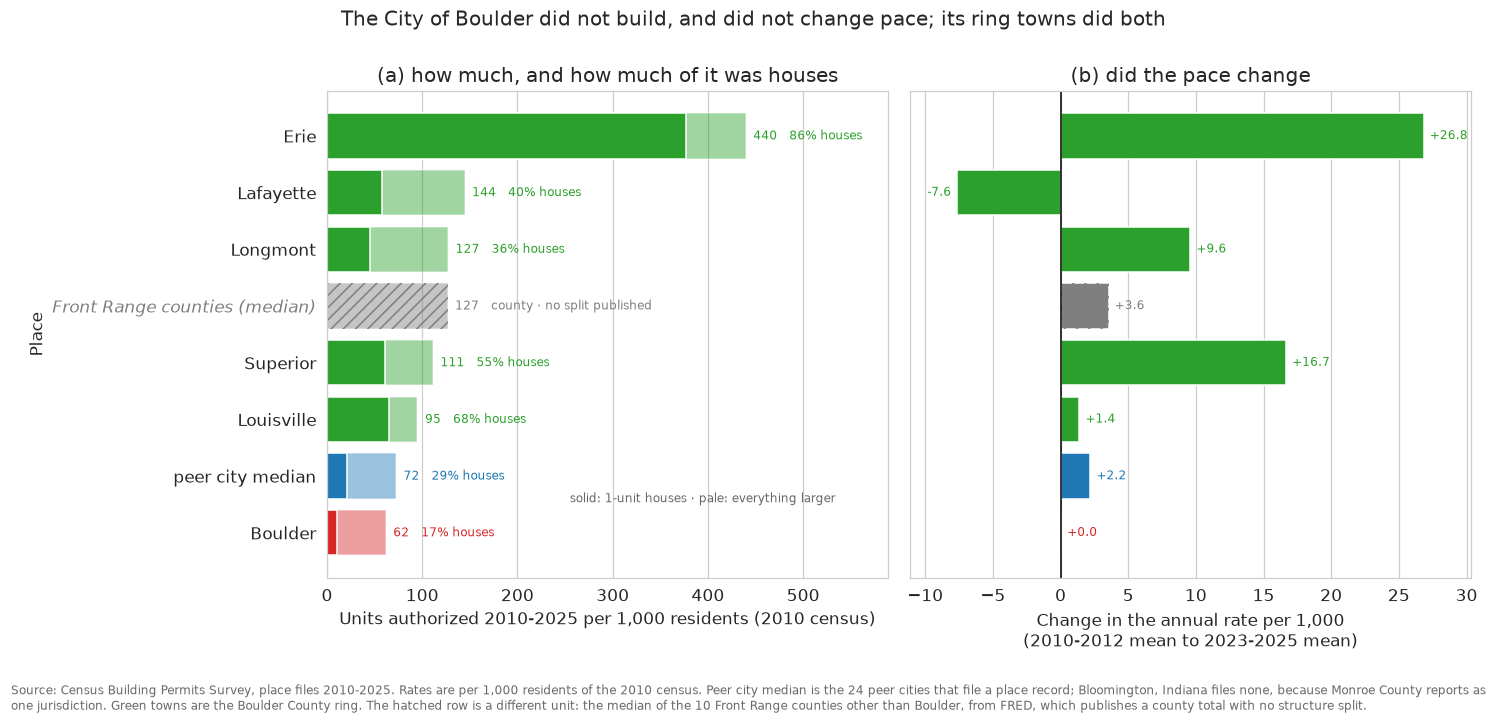

In [41]:
CHART_CITIES = ([('Boulder', BOULDER_C)]
                + [(name, RING_C) for name in ring_cities_df.sort_values('cum_per_1k').index])
MEDIAN_ROW = ('peer city median', PEER_C)
FAMILY_ALPHA = 0.45      # the paler part of each bar is everything that is not a 1-unit structure

rows_l = [(MEDIAN_ROW[0], MEDIAN_ROW[1], peer_cities_df['cum_per_1k'].median(),
           peer_cities_df['family_share'].median(), peer_cities_df['delta_per_1k'].median(), True)]
rows_l += [(name, color, city_permits_df.loc[name, 'cum_per_1k'],
            city_permits_df.loc[name, 'family_share'], city_permits_df.loc[name, 'delta_per_1k'], True)
           for name, color in CHART_CITIES]
# One county row, drawn differently: FRED publishes no structure split, so it cannot be divided
rows_l += [('Front Range counties (median)', CONTEXT,
            county_permit_rates_df.loc[front_range_l, 'cum_per_1k'].median(), np.nan,
            county_permit_rates_df.loc[front_range_l, 'delta_per_1k'].median(), False)]
chart_df = pd.DataFrame(rows_l, columns=['name', 'color', 'cum_per_1k', 'family_share',
                                         'delta_per_1k', 'is_city'])
chart_df = chart_df.sort_values('cum_per_1k').reset_index(drop=True)
chart_df['family_per_1k'] = chart_df['cum_per_1k'] * chart_df['family_share'] / 100

f, axes = plt.subplots(1, 2, figsize=(13.5, 6.0))
y = np.arange(len(chart_df))

ax = axes[0]
ax.barh(y, chart_df['cum_per_1k'], color=chart_df['color'], alpha=FAMILY_ALPHA)
ax.barh(y, chart_df['family_per_1k'].fillna(0), color=chart_df['color'])
# The county row is hatched, because it is a different unit and carries no structure split
c0 = ~chart_df['is_city']
ax.barh(y[c0], chart_df.loc[c0, 'cum_per_1k'], color='none',
        edgecolor=CONTEXT, hatch='///', linewidth=0)
# Both numbers ride at the end of the bar: a share printed inside a short solid segment clips
for yi, row in chart_df.iterrows():
    share = f'{row.family_share:.0f}% houses' if row.is_city else 'county · no split published'
    ax.annotate(f'{row.cum_per_1k:.0f}   {share}', (row.cum_per_1k, yi),
                fontsize=8, color=row.color, va='center', xytext=(5, 0), textcoords='offset points')
ax.set_yticks(y); ax.set_yticklabels(chart_df['name'])
ax.set_xlabel(f'Units authorized {PERMIT_START}-{PERMIT_END} per 1,000 residents (2010 census)')
for tick, is_city in zip(ax.get_yticklabels(), chart_df['is_city']):
    if not is_city:
        tick.set_color(CONTEXT); tick.set_style('italic')
ax.set_ylabel('Place')
ax.set_title('(a) how much, and how much of it was houses')
ax.set_xlim(0, chart_df['cum_per_1k'].max() * 1.34)
ax.grid(axis='y', visible=False)

ax = axes[1]
ax.barh(y, chart_df['delta_per_1k'], color=chart_df['color'])
ax.barh(y[c0], chart_df.loc[c0, 'delta_per_1k'], color='none',
        edgecolor=CONTEXT, hatch='///', linewidth=0)
for yi, value in enumerate(chart_df['delta_per_1k']):
    ax.annotate(f'{value:+.1f}', (value, yi), fontsize=8, color=chart_df['color'].iloc[yi],
                va='center', ha='left' if value >= 0 else 'right',
                xytext=(4 if value >= 0 else -4, 0), textcoords='offset points')
ax.axvline(0, color='k', lw=1)
ax.set_yticks(y); ax.set_yticklabels([])
ax.set_xlabel(f'Change in the annual rate per 1,000\n({EARLY_YEARS[0]}-{EARLY_YEARS[-1]} mean to '
              f'{LATE_YEARS[0]}-{LATE_YEARS[-1]} mean)')
ax.set_title('(b) did the pace change')
ax.set_xlim(chart_df['delta_per_1k'].min() - 3.5, chart_df['delta_per_1k'].max() + 3.5)
ax.grid(axis='y', visible=False)

# Name the fill convention once, in the clear space beside the shortest bars
axes[0].annotate('solid: 1-unit houses · pale: everything larger',
                 (chart_df['cum_per_1k'].max() * 0.58, 0.6), fontsize=8, color='dimgray',
                 va='center', ha='left')

f.suptitle('The City of Boulder did not build, and did not change pace; its ring towns did both',
           y=1.0)
f.text(0, -0.06, f'Source: Census Building Permits Survey, place files {PERMIT_START}-{PERMIT_END}. '
                 f'Rates are per 1,000 residents of the 2010 census. Peer city median is the '
                 f'{len(peer_cities_df)} peer cities that file a place record; Bloomington, Indiana '
                 f'files none, because Monroe County reports as one jurisdiction. Green towns are '
                 f'the Boulder County ring. The hatched row is a different unit: the median of the '
                 f'{len(front_range_l)} Front Range counties other than Boulder, from FRED, which '
                 f'publishes a county total with no structure split.', fontsize=8, color='dimgray',
       wrap=True)
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig9-building-permits.png', bbox_inches='tight')

The rows the chart draws, shaped for redrawing elsewhere, and the full city table behind them.

In [42]:
city_permits_df.round(2).to_csv(OUT / 'bvsd-fig9-building-permits.csv')
print(f"{len(city_permits_df)} cities written to {OUT / 'bvsd-fig9-building-permits.csv'}")

# The rows the chart actually draws, shaped for redrawing elsewhere. The two segment columns add
# to the total, so a stacked bar needs no arithmetic; the internal color column is dropped.
chart_export_df = pd.DataFrame({
    'name': chart_df['name'],
    'houses_per_1k': (chart_df['family_per_1k'].round(1)),
    'larger_per_1k': ((chart_df['cum_per_1k'] - chart_df['family_per_1k'].fillna(0)).round(1)),
    'total_per_1k': chart_df['cum_per_1k'].round(1),
    'house_share_pct': chart_df['family_share'].round(1),
    'delta_per_1k': chart_df['delta_per_1k'].round(1),
    'unit': np.where(chart_df['is_city'], 'city', 'county')})
chart_export_df = chart_export_df.iloc[::-1].reset_index(drop=True)   # top of the chart first

assert (chart_export_df['houses_per_1k'].fillna(0) + chart_export_df['larger_per_1k']
        - chart_export_df['total_per_1k']).abs().max() < 0.15, 'the two segments do not add to the total'
chart_export_df.to_csv(OUT / 'bvsd-fig9-building-permits-chart.csv', index=False)

print(f"\n{'=' * 78}\nCHART ROWS — paste into Datawrapper. houses_per_1k and larger_per_1k stack "
      f"to total_per_1k.\n{'=' * 78}")
print(chart_export_df.to_csv(index=False).strip())
chart_export_df

30 cities written to output/bvsd-fig9-building-permits.csv

CHART ROWS — paste into Datawrapper. houses_per_1k and larger_per_1k stack to total_per_1k.
name,houses_per_1k,larger_per_1k,total_per_1k,house_share_pct,delta_per_1k,unit
Erie,376.6,63.0,439.6,85.7,26.8,city
Lafayette,58.0,86.5,144.4,40.1,-7.6,city
Longmont,45.3,81.7,127.1,35.7,9.6,city
Front Range counties (median),,126.5,126.5,,3.6,county
Superior,60.8,50.4,111.2,54.7,16.7,city
Louisville,65.0,30.0,95.0,68.4,1.4,city
peer city median,21.1,51.3,72.4,29.2,2.2,city
Boulder,10.7,50.9,61.6,17.4,0.0,city


,name,houses_per_1k,larger_per_1k,total_per_1k,house_share_pct,delta_per_1k,unit
0,Erie,376.6,63.0,439.6,85.7,26.8,city
1,Lafayette,58.0,86.5,144.4,40.1,-7.6,city
2,Longmont,45.3,81.7,127.1,35.7,9.6,city
3,Front Range counties (median),NaN,126.5,126.5,NaN,3.6,county
4,Superior,60.8,50.4,111.2,54.7,16.7,city
5,Louisville,65.0,30.0,95.0,68.4,1.4,city
6,peer city median,21.1,51.3,72.4,29.2,2.2,city
7,Boulder,10.7,50.9,61.6,17.4,0.0,city


The City of Boulder authorized 62 units per 1,000 of its 2010 residents over sixteen years, against
a peer-city median of 72, and 17% of them were 1-unit houses against a peer median of 29%. Neither
number is an outlier on its own; Boulder sits 15th of 25 on the total and 16th of 25 on the house
share. The second panel is the one that is hard to explain away. Boulder's annual rate in 2023-2025
is the same as its rate in 2010-2012, to a tenth of a unit per thousand, while the median peer city
raised its rate by 2.2 and the median ring town by 9.6.

Erie is the comparison that matters, because it is eight miles away and inside the same county.
Erie authorized 440 units per 1,000 residents, 86% of them houses, and raised its annual rate by
26.8 per thousand, which is more than four times the City of Boulder's entire annual rate. Boulder
County's permit total, the number a county-grain chart would report, is 4.1 times the City of
Boulder's, and almost all of that difference is Erie, Longmont, Lafayette, Louisville and Superior.
At county grain Boulder reads as 84 per 1,000 against a Front Range median of 127 and a peer-county
median of 63: unremarkable, and about the wrong place. The hatched row in the chart is that Front
Range median. It is drawn differently because it is a different unit and FRED publishes no
structure split for it, and it lands level with Longmont, which is the point: the Front Range
counties build like Boulder's ring towns, not like Boulder.

Changing the denominator does not rescue the city either. Measured against the housing stock it was
added to rather than the people living in it, Boulder authorized 138 units per 1,000 of its 2010
housing units, or 13.8% stock growth over sixteen years, against a peer-city median of 17.3% and a
ring-town median of 31.3%. Erie's figure is 121%: it authorized more than it had. Both denominators
are carried in `output/bvsd-fig9-building-permits.csv`, along with the counted stock change from
each census. That last column is a consistency check and not a completion rate — it runs from 28%
to 258% across the basket, because annexation, conversion and demolition all move a counted stock
without appearing in this permit series.

This does not show that Boulder's land-use policy caused its enrollment decline, and no arithmetic
here could. What it shows is that the family-sized housing built in Boulder County over these
sixteen years was built almost entirely outside the city whose schools are now proposed for
closure, and that the city's own pace did not move while its neighbours' did. The district's list
of causes names low housing inventory as a fact about the region. At city grain it is not a
regional fact.

### What the comprehensive plan talked about

The [Boulder Valley Comprehensive Plan](https://bouldercolorado.gov/services/boulder-valley-comprehensive-plan)
is where the city's land-use policy is written down, and it has been rewritten fifteen times since
1977. Counting what its vocabulary attends to is a descriptive reading of what the policy
conversation was about. It is not evidence that the plan caused any demographic outcome.

The corpus is the Markdown conversion of fifteen editions, copied into `data/raw/bvcp/` from the
[2026-03 BVCP piece](https://github.com/brianckeegan/charting-boulder/tree/main/2026-03-bvcp).
Two of that piece's files are printings of the 1977 plan's 1978 revision, sharing 79 to 83 percent
of their sentences with each other, and are left out. The 2026 edition is the plan approved in
August 2026, converted from the approval document; it replaces the March 2026 draft that piece
used, which shares only a third of its sentences with the approved text and is kept in the folder
but not counted.

Three vocabularies are counted separately, each as a rate per 1,000 words. They are **not**
combined into a ratio: the ratio between any two of them is set by how many terms each list holds
and how common those words are, so it measures the word list rather than the plan.

Term choices that matter, each checked against the corpus:

- `famil*` is matched only where it is **not** preceded by single, multi, multiple or two. Without
  that exclusion, 177 of its 343 occurrences are "single-family" and similar, which is zoning
  vocabulary rather than attention to families.
- Character is matched as a phrase — neighborhood, community, historic or rural character — rather
  than as a stem. The bare stem picks up 270 occurrences of "characteristics" and "characterized".
- Housing affordability is kept apart from children and schools. Folding `afford*` into the
  children vocabulary would have carried almost all of that series' movement, and would have
  reported a housing finding under a schools heading.
- The counting functions come from `bvcp-corpus-analysis.ipynb`, with one change: that notebook
  counts exact single tokens, which cannot see a phrase or a stem. `bvsd-retrieval.ipynb` matches
  each term as a phrase or word-prefix over the cleaned text, and writes one count per edition per
  term. Counting by term rather than by family is what lets the next cell drop any single word and
  see where the finding moves.

In [43]:
bvcp_terms_df = pd.read_csv(PROC / 'bvcp-term-counts.csv')

# Rates are per 1,000 words of cleaned text, so a longer edition does not score higher for length
bvcp_terms_df['rate_per_1k'] = bvcp_terms_df['count'] / bvcp_terms_df['word_count'] * 1000
# Reading order, not alphabetical: the argument moves from preservation to children to cost
FAMILY_ORDER = ['Preservation', 'Children & schools', 'Housing affordability']
assert set(FAMILY_ORDER) == set(bvcp_terms_df['family']), 'the term table holds different families'
bvcp_terms_df['family'] = pd.Categorical(bvcp_terms_df['family'], FAMILY_ORDER, ordered=True)

KEYWORD_FAMILIES = {family: sorted(frame['term'].unique())
                    for family, frame in bvcp_terms_df.groupby('family', observed=True)}
EDITION_YEARS = sorted(bvcp_terms_df['year'].unique().tolist())

family_rates_df = (bvcp_terms_df.groupby(['version', 'year', 'family'], as_index=False, observed=True)
                   .agg(raw_count=('count', 'sum'), rate_per_1k=('rate_per_1k', 'sum'))
                   .sort_values(['year', 'family']).reset_index(drop=True))
vocabulary_df = family_rates_df.pivot(index='year', columns='family', values='rate_per_1k')
words_s = bvcp_terms_df.groupby('year')['word_count'].first()

# Integrity checks
assert len(EDITION_YEARS) == 15, f'expected 15 editions; got {len(EDITION_YEARS)}'
assert words_s.gt(10_000).all(), 'an edition converted to near-empty text'
assert (bvcp_terms_df.groupby('family', observed=True)['count'].sum() > 0).all(), 'a family scored zero'
assert vocabulary_df.notna().all().all(), 'an edition is missing a family'

print(f"{len(EDITION_YEARS)} editions, {words_s.sum():,} words total")
for family in vocabulary_df:
    family_s = vocabulary_df[family]
    print(f'{family:22s} 1977 {family_s.iloc[0]:5.2f} · peak {family_s.max():5.2f} ({int(family_s.idxmax())}) · '
          f'2026 {family_s.iloc[-1]:5.2f} per 1,000 words')
vocabulary_df.round(2)

15 editions, 710,678 words total
Preservation           1977  4.58 · peak  6.39 (2015) · 2026  4.65 per 1,000 words
Children & schools     1977  0.95 · peak  1.97 (2001) · 2026  1.56 per 1,000 words
Housing affordability  1977  0.00 · peak  1.49 (2026) · 2026  1.49 per 1,000 words


family,Preservation,Children & schools,Housing affordability
year,,,
1977,4.58,0.95,0.00
1978,3.25,0.63,0.00
1979,2.83,0.62,0.00
1981,2.93,1.88,0.02
1983,3.18,1.75,0.11
1986,3.29,1.94,0.11
1990,3.03,1.86,0.28
1996,3.98,1.66,0.70
2001,4.92,1.97,0.92


### Leave one term out

A finding that depends on one word is a finding about the word list, so each term is dropped in
turn and the endpoints re-read.

In [44]:
# Robustness: drop each term in turn and see where the endpoints move. A finding that depends
# on one word is a finding about the word list. Family rates are sums of term rates, so dropping
# a term is a subtraction, not a re-count.
term_rate_df = bvcp_terms_df.pivot_table(index='year', columns=['family', 'term'],
                                         values='rate_per_1k')
print('Leave-one-out endpoints, per 1,000 words:')
for family, terms_l in KEYWORD_FAMILIES.items():
    full_s = vocabulary_df[family]
    if len(terms_l) < 2:
        print(f'  {family:22s} single term, nothing to drop')
        continue
    dropped_df = full_s.to_frame('full').join(term_rate_df[family])
    first_l = [full_s.iloc[0] - dropped_df[term].iloc[0] for term in terms_l]
    last_l = [full_s.iloc[-1] - dropped_df[term].iloc[-1] for term in terms_l]
    print(f'  {family:22s} 1977 {full_s.iloc[0]:.2f} (range {min(first_l):.2f}-{max(first_l):.2f}) · '
          f'2026 {full_s.iloc[-1]:.2f} (range {min(last_l):.2f}-{max(last_l):.2f})')

children_1977 = vocabulary_df['Children & schools'].iloc[0]
children_2026 = vocabulary_df['Children & schools'].iloc[-1]
children_peak_year = int(vocabulary_df['Children & schools'].idxmax())
preservation_1977 = vocabulary_df['Preservation'].iloc[0]
preservation_peak = vocabulary_df['Preservation'].max()
preservation_peak_year = int(vocabulary_df['Preservation'].idxmax())
preservation_2026 = vocabulary_df['Preservation'].iloc[-1]
afford_2026 = vocabulary_df['Housing affordability'].iloc[-1]
afford_crossover = int(vocabulary_df.index[vocabulary_df['Housing affordability']
                                           > vocabulary_df['Children & schools']].min())
print(f'\nHousing affordability first exceeds children and schools in {afford_crossover}, '
      f'and by {vocabulary_df.index[-1]} it is {afford_2026 / children_2026:.1f} times as common.')

Leave-one-out endpoints, per 1,000 words:
  Preservation           1977 4.58 (range 2.08-4.58) · 2026 4.65 (range 2.49-4.65)
  Children & schools     1977 0.95 (range 0.54-0.95) · 2026 1.56 (range 0.89-1.49)
  Housing affordability  single term, nothing to drop

Housing affordability first exceeds children and schools in 2015, and by 2026 it is 1.0 times as common.


The three vocabularies over fifteen editions, each with its own colour and marker.

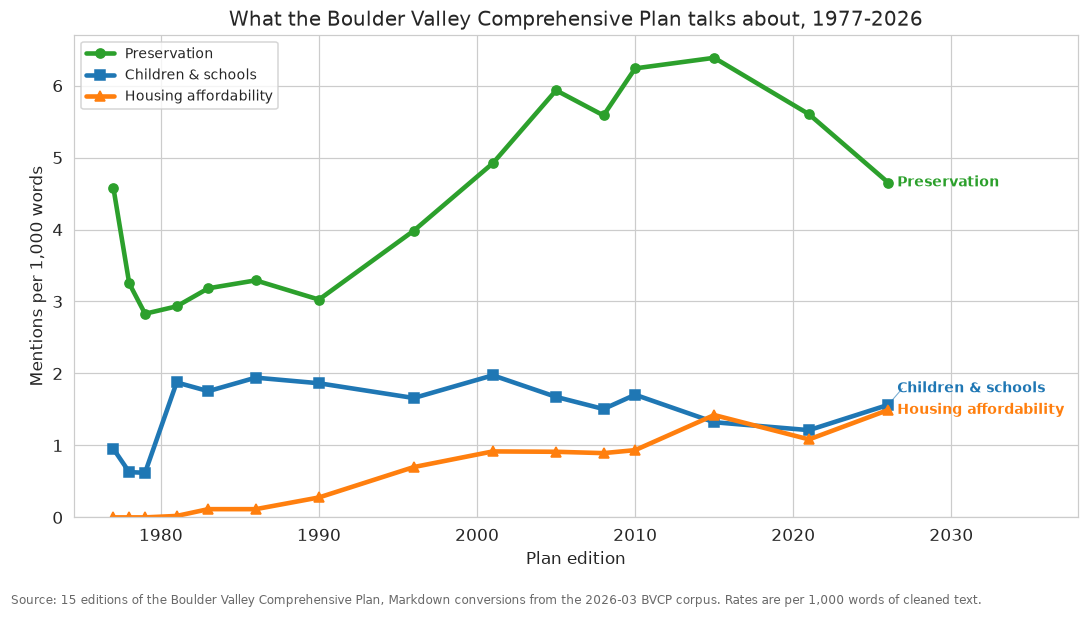

In [45]:
f, ax = plt.subplots(figsize=(10, 5.4))
# Three markers as well as three colours: green and orange merge under protanopia
for (family, color), marker in zip(VOCAB_COLORS_D.items(), ['o', 's', '^']):
    family_s = vocabulary_df[family]
    ax.plot(family_s.index, family_s, color=color, lw=3, marker=marker, markersize=6, label=family)
# Two series end within a tenth of a point of each other, so the end labels are spaced apart
label_ends(ax, [(family, vocabulary_df[family].iloc[-1], color) for family, color in VOCAB_COLORS_D.items()],
           vocabulary_df.index[-1], 0.3)
ax.set_ylabel('Mentions per 1,000 words')
ax.set_xlabel('Plan edition')
ax.set_ylim(0)
ax.set_xlim(right=vocabulary_df.index[-1] + 12)
ax.set_title('What the Boulder Valley Comprehensive Plan talks about, 1977-2026')
ax.legend(loc='upper left', fontsize=9)
f.text(0, -0.03, 'Source: 15 editions of the Boulder Valley Comprehensive Plan, Markdown conversions '
                 'from the 2026-03 BVCP corpus. Rates are per 1,000 words of cleaned text.',
       fontsize=8, color='dimgray')
plt.tight_layout()
f.savefig(OUT / 'bvsd-fig10-plan-vocabulary.png', bbox_inches='tight')

## What the close needs

The column's close asks the district to say which of the two futures it is planning for, and to
commit to one bounded round of closures. Both asks depend on numbers computed above. This section
carries each fork through the district's own arithmetic — the capture ratio, and the K-5 capacity
implied by the plan's own 68-to-75 percent utilization target — and reports when utilization
troughs under each.

The Hamilton-Perry projection reports five-year age groups, so its K-5 cohort takes the 5-9 group
plus a fifth of the 10-14 group. That is an assumption about ages within a group, and it is one of
two interpolations in this notebook; the other holds the 15-17 share of the 15-19 group at its 2020
value in the fork above.

In [46]:
K5_CAPACITY_POST = K5_ENROLL_2025_26 / UTIL_POST     # capacity implied by the plan's 75% target

# The state's fork, annually
sdo_util_s = resident_df.loc[2025:, 'age_5_10'] * capture_k5 / K5_CAPACITY_POST * 100

# The cohort fork, at its ten-year steps. 2020 is the launch year, not a projection, so the
# trough is taken over the projected decades only.
hp_k5_s = pd.Series({year: vec[G[5]] + 0.2 * vec[G[10]] for year, vec in hp_chain_d.items()}).sort_index()
hp_util_s = (hp_k5_s * capture_k5 / K5_CAPACITY_POST * 100).loc[PROJ_YEARS]

sdo_trough_year, sdo_trough_util = int(sdo_util_s.idxmin()), sdo_util_s.min()
hp_trough_year, hp_trough_util = int(hp_util_s.idxmin()), hp_util_s.min()
# Same grid, so the two troughs are comparable rather than one annual and one decadal
sdo_util_decadal_s = sdo_util_s.reindex(PROJ_YEARS)
sdo_decadal_trough_year = int(sdo_util_decadal_s.idxmin())

print(f'post-plan K-5 capacity implied by the {UTIL_POST:.0%} target: {K5_CAPACITY_POST:,.0f} seats')
print(f'\nK-5 utilization of the post-consolidation system, state fork (annual, 2025-{SDO_LAST_YEAR})')
print(f'  trough {sdo_trough_util:.0f}% in {sdo_trough_year}; {sdo_util_s.loc[2060]:.0f}% by 2060')
print(f'\nOn the decades both forks share ({", ".join(str(y) for y in PROJ_YEARS)}):')
print(f'  state fork:  trough {sdo_util_decadal_s.min():.0f}% in {sdo_decadal_trough_year}, '
      f'{sdo_util_decadal_s.loc[2060]:.0f}% by 2060')
print(f'  cohort fork: trough {hp_trough_util:.0f}% in {hp_trough_year}, '
      f'{hp_util_s.loc[2060]:.0f}% by 2060')
print(f'\nThe two forks differ by {abs(hp_util_s.loc[2060] - sdo_util_s.loc[2060]):.0f} percentage points of '
      'utilization by 2060 on the same capacity. Under one the consolidated system settles near its '
      'target; under the other the district needs the seats back.')
print('The cohort fork moves in ten-year steps, so its trough year is resolved to a decade, not a year.')
pd.DataFrame({'state fork': sdo_util_decadal_s, 'cohort fork': hp_util_s}).round(1)

post-plan K-5 capacity implied by the 75% target: 12,976 seats

K-5 utilization of the post-consolidation system, state fork (annual, 2025-2060)
  trough 72% in 2029; 75% by 2060

On the decades both forks share (2030, 2040, 2050, 2060):
  state fork:  trough 72% in 2030, 75% by 2060
  cohort fork: trough 97% in 2030, 113% by 2060

The two forks differ by 38 percentage points of utilization by 2060 on the same capacity. Under one the consolidated system settles near its target; under the other the district needs the seats back.
The cohort fork moves in ten-year steps, so its trough year is resolved to a decade, not a year.


,state fork,cohort fork
2030,72.1,96.6
2040,78.3,103.6
2050,82.2,109.8
2060,75.1,112.9


## Pinned headline numbers

Every number the column cites appears below, computed from a cell above rather than typed in.
The table is written to `output/bvsd-pinned.csv`.

In [47]:
pinned_s = pd.Series({
    # The district's own baseline
    'vote_date': VOTE_DATE,
    'capture_ratio_k5_2025': round(capture_k5, 3),
    'capture_ratio_k12_2020': round(capture_k12, 3),
    'k5_2030_modeled': round(k5_2030_sdo),
    'util_2030_current_capacity_pct': round(util_2030_current * 100, 1),
    'k12_loss_2025_2030_modeled': round(k12_loss_2025_2030),
    'k12_loss_2025_2030_district': LOSS_5YR,
    # Peer comparison
    'boulder_5_17_change_2010_2020_pct': round(boulder_sa_chg_10_20, 1),
    'peer_median_5_17_change_2010_2020_pct': round(peer_sa_chg_10_20, 1),
    'boulder_under5_change_2010_2020_pct': round(boulder_u5_chg_10_20, 1),
    'peer_median_under5_change_2010_2020_pct': round(peer_u5_chg_10_20, 1),
    'boulder_under5_steeper_than_pct_of_peers': round(u5_steeper_pct),
    'boulder_0_9_vs_implied_2020_pct': round(boulder_implied_gap, 1),
    'boulder_0_9_gap_steeper_than_pct_of_peers': round(implied_steeper_pct),
    'boulder_0_4_per_100_of_10_14_2020': round(boulder_replacement),
    # The state's own forecast by age, Boulder County against the Front Range
    'sdo_boulder_county_5_9_change_2020_2050_pct': round(sdo_profile_df.loc['5-9', 'Boulder'], 1),
    'sdo_boulder_county_10_17_change_2020_2050_pct': round(sdo_profile_df.loc['10-17', 'Boulder'], 1),
    'sdo_front_range_median_5_9_change_2020_2050_pct': round(sdo_profile_df.loc['5-9', 'front_range_median'], 1),
    'sdo_front_range_median_10_17_change_2020_2050_pct': round(sdo_profile_df.loc['10-17', 'front_range_median'], 1),
    'sdo_colorado_less_boulder_10_17_change_2020_2050_pct': round(sdo_profile_df.loc['10-17', 'colorado_ex_boulder'], 1),
    'sdo_boulder_beats_front_range_buckets': int((sdo_profile_df.gap_points > 0).sum()),
    'front_range_comparison_counties': len(comparison_counties_l),
    # Building permits, city grain
    'boulder_city_permits_per_1k_2010_2025': round(boulder_permits_s.cum_per_1k, 1),
    'peer_city_median_permits_per_1k_2010_2025': round(peer_cities_df.cum_per_1k.median(), 1),
    'ring_town_median_permits_per_1k_2010_2025': round(ring_cities_df.cum_per_1k.median(), 1),
    'boulder_city_1unit_share_pct': round(boulder_permits_s.family_share, 1),
    'peer_city_median_1unit_share_pct': round(peer_cities_df.family_share.median(), 1),
    'boulder_city_permit_rate_delta_per_1k': round(boulder_permits_s.delta_per_1k, 1),
    'peer_city_median_permit_rate_delta_per_1k': round(peer_cities_df.delta_per_1k.median(), 1),
    'erie_permits_per_1k_2010_2025': round(city_permits_df.loc['Erie', 'cum_per_1k'], 1),
    'boulder_county_over_city_permit_ratio': round(boulder_county_s.cum_units / boulder_permits_s.cum_units, 1),
    'boulder_city_permits_per_1k_stock': round(boulder_permits_s.cum_per_1k_stock, 1),
    'peer_city_median_permits_per_1k_stock': round(peer_cities_df.cum_per_1k_stock.median(), 1),
    'ring_town_median_permits_per_1k_stock': round(ring_cities_df.cum_per_1k_stock.median(), 1),
    'front_range_county_median_permits_per_1k': round(county_permit_rates_df.loc[front_range_l, 'cum_per_1k'].median(), 1),
    'acs_under5_median_moe_pct': round(acs_median_moe_pct, 1),
    'acs_under5_mean_abs_year_change': round(acs_mean_abs_year_change),
    'decennial_under5_change_2010_2020': round(decennial_under5_change),
    # The fork
    'backtest_median_abs_error_pct': round(backtest_median_abs_error, 1),
    'fork_5_17_sdo_2060': round(fork_df.loc[2060, 'sdo_5_17']),
    'fork_5_17_hp_2060': round(fork_df.loc[2060, 'hp_5_17']),
    'fork_gap_2030_pct': round(gap_2030, 1),
    'fork_gap_2050_pct': round(gap_2050, 1),
    'fork_gap_2060_pct': round(gap_2060, 1),
    # Mechanism
    'births_change_2000_2024_pct': round(births_change_pct, 1),
    'natural_decrease_first_year': natural_decrease_year,
    'net_migration_2015_2024_mean': round(netmig_recent),
    'households_with_kids_share_2010_pct': round(hh_share_2010, 1),
    'households_with_kids_share_2025_pct': round(hh_share_2025, 1),
    'households_with_kids_share_2050_pct': round(hh_share_2050, 1),
    'household_series_last_year': HOUSEHOLD_LAST_YEAR,
    'county_hpi_multiple_since_1975': round(hpi_growth_since_1975, 1),
    'price_income_index_base_year': INDEX_BASE,
    'price_income_ratio_boulder_latest': round(boulder_ratio_latest),
    'price_income_ratio_peer_median_latest': round(peer_ratio_latest_s.median()),
    'price_income_ratio_front_range_median_latest': round(fr_ratio_latest_s.median()),
    'front_range_housing_counties': len(front_range_housing_l),
    'price_income_ratio_latest_year': latest_ratio_year,
    'price_income_boulder_above_pct_of_peers': round(boulder_pctile),
    'bvcp_preservation_1977': round(preservation_1977, 2),
    'bvcp_preservation_peak': round(preservation_peak, 2),
    'bvcp_preservation_peak_year': preservation_peak_year,
    'bvcp_preservation_2026': round(preservation_2026, 2),
    'bvcp_children_schools_1977': round(children_1977, 2),
    'bvcp_children_schools_peak_year': children_peak_year,
    'bvcp_children_schools_2026': round(children_2026, 2),
    'bvcp_affordability_2026': round(afford_2026, 2),
    'bvcp_affordability_passes_children_year': afford_crossover,
    # The close
    'post_plan_k5_capacity': round(K5_CAPACITY_POST),
    'util_trough_year_sdo_fork': sdo_trough_year,
    'util_trough_pct_sdo_fork': round(sdo_trough_util, 1),
    'util_trough_year_hp_fork': hp_trough_year,
    'util_trough_pct_hp_fork': round(hp_trough_util, 1),
    'util_2060_pct_sdo_fork': round(sdo_util_s.loc[2060], 1),
    'util_2060_pct_hp_fork': round(hp_util_s.loc[2060], 1),
    'fork_total_population_gap_2060_pct': round(total_gap_2060, 1),
}, name='value')

pinned_s.to_csv(OUT / 'bvsd-pinned.csv')
fork_df.round(1).to_csv(OUT / 'bvsd-fork-5-17.csv')
observed_df.round(2).to_csv(OUT / 'bvsd-peer-observed.csv')
family_rates_df.round(3).to_csv(OUT / 'bvsd-plan-vocabulary.csv')
print(f'{len(pinned_s)} numbers pinned to {OUT / "bvsd-pinned.csv"}\n')
pinned_s.to_frame()

76 numbers pinned to output/bvsd-pinned.csv



,value
vote_date,"September 22, 2026"
capture_ratio_k5_2025,0.437
capture_ratio_k12_2020,0.481
k5_2030_modeled,9349
util_2030_current_capacity_pct,64.1
...,...
util_trough_year_hp_fork,2030
util_trough_pct_hp_fork,96.6
util_2060_pct_sdo_fork,75.1
util_2060_pct_hp_fork,112.9


### What this notebook does not establish

1. **No causal claim.** The plan-vocabulary series, the price series and the demographic series are
   described together because they move together. Nothing here identifies an effect of land-use
   policy on births, prices, or enrollment.
2. **The cohort projection is not a forecast.** It carries the 2010-to-2020 transition forward
   unchanged. That decade contained the 2000s birth echo moving through Boulder's schools, so the
   projection inherits it. Hamilton-Perry is validated in the literature to roughly fifteen years;
   2060 is forty years past the launch, and the backtest error above is a floor on uncertainty
   rather than a confidence interval.
3. **The cohort fork's extra children come with extra adults.** Carrying the 2010s forward gives
   the two counties 22 percent more residents in 2060 than the state forecast does. Reading its
   child counts as a future means accepting that growth as well; it is not a claim that Boulder
   becomes more child-dense.
4. **The state forecast is not an observation either.** Its post-2025 recovery rests on assumptions
   about fertility and migration. Presenting both forks is the point; picking one silently would
   be the error.
5. **County is not district.** Boulder County contains St. Vrain Valley territory and Broomfield is
   split between districts. The capture ratio absorbs that as a share, anchored on one K-12 count
   and one K-5 count.
6. **The 2020 census distorts college towns.** April 2020 enumeration sent students home, which
   moves the 18-24 counts feeding the 2010-to-2020 cohort ratios for Boulder and much of its peer
   basket.
7. **Annexation sits inside the cohort ratios.** A place that grew by annexing family
   subdivisions shows cohort gains that are not migration into a fixed area. Boulder's growth
   boundary makes it unusually clean; several peers are not.
8. **The vocabulary counts are surface matches.** They count what the plan says, not what it did.
   "Open space" carries a Boulder-specific administrative meaning alongside its plain one, and the
   leave-one-out table above shows how far each series moves when any single term is dropped. The
   three vocabularies are reported separately and never divided into each other, because a ratio
   between two word lists measures the lists.
9. **The annual survey cannot referee the decennial finding.** The American Community Survey's
   one-year under-5 estimate for a city of Boulder's size carries a margin of error near a quarter
   of the estimate, and swings between consecutive years by more than the decennial count moved
   across the whole 2010s. It is reported above as a check that failed to resolve, not as
   corroboration.
10. **It does not forecast enrollment.** The state's projection and this notebook's cohort
   projection are both carried, and they disagree; neither is adjudicated here, and no figure
   should be read as a prediction of how many children will enrol.